# UBS and JPMorgan earnings calls: Phases 1 to 4 for the whole team

Willian Angelo · Team 10 · Bank of England employer project (CAM_DS_401) · release `2026-09-23`

Every step of Phases 1 to 4 in the team plan (`workflow_data.md`, Section 8), including the steps owned by Team A (Roman, John, Rachel) and by Jack, in one notebook. It is a reference and a cross-check for the team's own notebooks, not a replacement for them. It stops at the gold set. A side section at the end has Laya label the gold set and compares it with the other methods.

The first comment line of each code cell gives its step and the plan step it covers. The model scope is the team's four families; this notebook uses two of them, BERTopic and Sentence-BERT. Laya, in the side section, is outside that scope.

This notebook is its own branch, apart from `angelo.ipynb`. It reads the embedding cache in `notebooks/angelo/outputs/2026-09-23/` (checked against the row keys) and writes everything else, including its gold set, label sheets and the Laya run, to `notebooks/angelo/outputs/2026-09-23/full/`.

Outputs print transcript text. **Clear all outputs before every commit** (public repo, N23).

## Environment

Phase 0 is already set up: same repo, `.venv` and data as `angelo.ipynb`. Run these three cells in order.

In [2]:
# 0.0 local Windows only, run before the setup cell: pandas loads pyarrow, whose bundled msvcp140.dll
# is older than the one torch needs, and torch then fails with WinError 1114. Harmless in Colab.
import torch

> **Business view.** A technical safety step with no analysis in it. On Windows, two libraries clash if they load in the wrong order, and the embedding models then refuse to start (R19). Loading PyTorch first keeps the pipeline repeatable on any team laptop. That matters because a supervisor has to be able to rerun the same analysis and get the same numbers.

In [3]:
# project setup - run first, do not edit except NAME
NAME = "angelo"  # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.13.15  pandas 2.2.3  data c:\local_CAM\Emp_Proj\boe-financial-analysis\data


> **Business view.** The team's standard start-up cell. It finds the project folder, syncs the code with the shared `main` branch, installs the pinned library versions and checks the environment. The output confirms Python 3.13.15 and pandas 2.2.3, the same versions as the rest of the team, so any number on our slides can be reproduced by a teammate or by a Bank of England reviewer.

In [4]:
# 0.2 pin the release; never use loading.LATEST, which points at the wrong folder (N18)
EXPORT = "2026-09-23"
PREVIOUS = "2026-09-13"      # the release before the contraction fix, read once in step 1.3
print("releases on disk:", loading.exports(DATA))

releases on disk: ['2026-09-13', '2026-09-23', 'Never ever upload or change something in the folder above']


> **Business view.** Fixes the analysis to the 23 September release and names the previous one (13 September), which step 1.3 reads once to prove the text fix. The list still shows the warning folder that breaks `loading.LATEST` (N18); naming the release avoids it.

## Data import and cleaning

Owner in the team plan: Team A (Roman, John). Two paths (N13). The **transformer path** keeps the raw sentences and drops filler sentences as whole rows (1.6 to 1.8). The **bag-of-words path** lower-cases, removes stop words and lemmatises (1.10, 1.11); it feeds word counts and topic labels only, never a transformer model.

In [5]:
# 1.0 settings shared by every phase
try:
    import torch
except OSError as e:
    raise OSError("torch failed to load because pandas loaded first: restart the kernel "
                  "and run the 0.0 cell before the setup cell") from e
import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for name in ("ROOT", "DATA", "EXPORT", "loading"):
    if name not in globals():
        raise NameError(f"run the Environment cell first: {name} is not defined")
if EXPORT not in loading.exports(DATA):
    raise FileNotFoundError(f"release {EXPORT} is not in {DATA / 'results'}")

SEED = 42
SHARED = ROOT / "notebooks" / "angelo" / "outputs" / EXPORT   # shared with angelo.ipynb: embedding cache and gold set
OUT = SHARED / "full"                                         # this notebook's own outputs; outputs/ is kept out of git (N23)
if DATA in OUT.parents:
    raise RuntimeError(f"never write inside {DATA}: it holds the read-only release")
OUT.mkdir(parents=True, exist_ok=True)

BANKS = ["UBS", "JPM"]
ROLES = ["analyst", "management"]
QUARTERS = [f"{y}-Q{q}" for y in (2023, 2024) for q in (1, 2, 3, 4)]
CALL_ID = ["bank", "quarter", "call_type"]
TURN = CALL_ID + ["position_in_call"]
KEY = TURN + ["sentence_number"]               # joins results across releases (T20)

# deal stage per call (proposed framing, N1); every call after 2023-Q2 is integration
STAGE = {("UBS", "2023-Q1"): "announced", ("UBS", "2023-Q2"): "closing",
         ("JPM", "2023-Q1"): "before",    ("JPM", "2023-Q2"): "closing"}
STAGE_GROUPS = ["early", "closing", "integration"]

# breaks marked on every time chart (N7)
BREAKS = {"UBS": ("2023-Q2", "Credit Suisse consolidated"),
          "JPM": ("2024-Q2", "Visa gain, CFO-only call")}

# chart style: one fixed colour per bank, recessive grid and axes
BANK_COLOR = {"UBS": "#2a78d6", "JPM": "#eb6834"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})
print(f"release {EXPORT}   outputs {OUT}")

release 2026-09-23   outputs c:\local_CAM\Emp_Proj\boe-financial-analysis\notebooks\angelo\outputs\2026-09-23\full


> **Business view.** Sets the ground rules for the whole analysis: two banks, eight quarters (2023-Q1 to 2024-Q4), a fixed random seed so results repeat, and one output folder. It also records two business judgements. First, each call gets a deal stage. UBS announced the Credit Suisse rescue in 2023-Q1 and closed it in 2023-Q2, JPMorgan bought First Republic in 2023-Q2, and every later call counts as integration. Second, it marks the two quarters where the reported numbers jump for known reasons (Credit Suisse consolidated into UBS; JPMorgan's one-off Visa gain), so nobody reads those jumps as a change in behaviour. This notebook writes its own outputs to `notebooks/angelo/outputs/2026-09-23/full/` (kept out of git, because they hold transcript text) and reads the embedding cache saved by `angelo.ipynb`, so both notebooks work from the same vectors.

In [6]:
# 1.1 load the pinned release (plan step 1.1)
sent_raw = loading.load(DATA, "all_sentences.csv", EXPORT)
utt_raw = loading.load(DATA, "all_utterances.csv", EXPORT)
metrics = loading.load(DATA, "all_metrics.csv", EXPORT)

loaded all_sentences.csv  9519 rows
loaded all_utterances.csv  1201 rows
loaded all_metrics.csv  510 rows


> **Business view.** Loads the three tables of the release: 9,519 sentences, 1,201 speaker turns and 510 reported financial metrics. The metrics let us set what executives *say* on the call next to what the banks *report* in their results.

In [7]:
# 1.2 data tests (plan step 1.10): stop if the release is not what the README describes
FUSED = re.compile(r"\b(?:do|did|does|would|wo|have|are|should|ca|is|was|has|had|were|could)not\b", re.I)
linked = sent_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
event_calls = set(sent_raw.loc[sent_raw["call_type"] == "event", ["bank", "quarter"]]
                  .itertuples(index=False, name=None))

checks = {
    "9,519 sentences, 1,201 utterances, 510 metric rows":
        (len(sent_raw), len(utt_raw), len(metrics)) == (9519, 1201, 510),
    "sentence_id unique": sent_raw["sentence_id"].is_unique,
    "cross-release key unique": not sent_raw.duplicated(KEY).any(),
    "no nulls in key columns or text":
        sent_raw[KEY + ["section", "speaker_role", "sentence"]].notna().all().all(),
    "section and role values as documented":
        set(sent_raw["section"]) <= {"prepared", "qa"}
        and set(sent_raw["speaker_role"]) <= {"management", "analyst", "ir", "operator"},
    "one event call, JPM 2023-Q2": event_calls == {("JPM", "2023-Q2")},
    "every sentence links to its utterance": linked["_merge"].eq("both").all(),
    "no fused negations left (R13, R15)": not sent_raw["sentence"].str.contains(FUSED).any(),
}
print(pd.Series(checks).map({True: "pass", False: "FAIL"}).to_string())
failed = [name for name, ok in checks.items() if not ok]
if failed:
    raise AssertionError(f"release checks failed: {failed}")

9,519 sentences, 1,201 utterances, 510 metric rows    pass
sentence_id unique                                    pass
cross-release key unique                              pass
no nulls in key columns or text                       pass
section and role values as documented                 pass
one event call, JPM 2023-Q2                           pass
every sentence links to its utterance                 pass
no fused negations left (R13, R15)                    pass


> **Business view.** Eight automatic checks that the data matches what the data owner documented: row counts, unique IDs, no missing values, valid categories, the single non-earnings call (JPMorgan's 2023-Q2 investor event), and that an earlier text defect is fixed ("do not" glued into "donot", R15). All eight pass. If a future release breaks any of them, the notebook stops before producing wrong numbers. For a regulator, a silent data error is worse than no analysis.

In [8]:
# 1.3 contraction fix (plan step 1.3, R13, R15): the previous release against this one, on the cross-release key.
# "Testing caught it, the pipeline fixed it" for the cleaning slide. Prints transcript text: clear outputs before committing.
old = loading.load(DATA, "all_sentences.csv", PREVIOUS)
rel = sent_raw.merge(old, on=KEY, how="outer", suffixes=("", "_old"), indicator=True)
matched = rel[rel["_merge"] == "both"]
changed = matched[matched["sentence"] != matched["sentence_old"]]
other_cols = ["section", "speaker_role", "speaker_name", "speaker_institution", "call_date"]
fused_words = pd.Series(FUSED.findall(" ".join(old["sentence"]))).str.lower().value_counts()
fix = pd.Series({
    "sentences matched on the key": len(matched),
    "sentences in only one release": int((rel["_merge"] != "both").sum()),
    "fused negations in the previous release": int(fused_words.sum()),
    "fused negations in this release": int(sent_raw["sentence"].str.count(FUSED).sum()),
    "sentences whose text changed": len(changed),
    "changed sentences that now contain n't": int(changed["sentence"].str.contains(r"n[’']t\b").sum()),
    "values changed in other columns": int(sum((matched[c].fillna("") != matched[f"{c}_old"].fillna("")).sum()
                                               for c in other_cols)),
})
print(fix.to_string())
print("\nfused words in the previous release:", fused_words.to_dict())
for _, r in changed.sample(3, random_state=SEED).iterrows():
    print(f"\n  before: {r['sentence_old'][:150]}\n  after:  {r['sentence'][:150]}")

loaded all_sentences.csv  9519 rows
sentences matched on the key               9519
sentences in only one release                 0
fused negations in the previous release     386
fused negations in this release               0
sentences whose text changed                359
changed sentences that now contain n't      359
values changed in other columns               0

fused words in the previous release: {'donot': 182, 'wonot': 30, 'wouldnot': 28, 'didnot': 24, 'doesnot': 23, 'havenot': 19, 'canot': 16, 'isnot': 14, 'arenot': 13, 'shouldnot': 11, 'wasnot': 9, 'hasnot': 8, 'werenot': 4, 'hadnot': 3, 'couldnot': 2}

  before: While we donot expect much of a financial impact from it, we have a presence in the area across all three lines of business, so we're keeping in close
  after:  While we don't expect much of a financial impact from it, we have a presence in the area across all three lines of business, so we're keeping in close

  before: We donot know when that's going to happen.


> **Business view.** Proves the text fix Roman made after the team's EDA found the defect. The previous release had 386 negations glued together ("donot" 182 times, "wonot" 30, "wouldnot" 28), which hides the "not" from a language model, so "we do not expect losses" reads like "we expect losses". This release has none: exactly 359 sentences changed, all by getting their "n't" back, and nothing else in the data moved. It is the "testing caught it, the pipeline fixed it within a day" story for the cleaning slide, now backed by numbers.

In [9]:
# 1.4 working columns: deal stage, a turn id per utterance and a text key per sentence
def add_columns(df):
    df = df.copy()
    df["stage"] = [STAGE.get(bq, "integration") for bq in zip(df["bank"], df["quarter"])]
    df["stage_group"] = df["quarter"].map({"2023-Q1": "early", "2023-Q2": "closing"}).fillna("integration")
    df["turn_id"] = df[TURN].astype(str).agg("|".join, axis=1)
    return df

sent = add_columns(sent_raw)
utt = add_columns(utt_raw)
sent["key"] = sent[KEY].astype(str).agg("|".join, axis=1)

> **Business view.** Adds three labels to every sentence: its deal stage, the speaker turn it came from, and a unique key. The key lets us join our results with teammates' results (Jack's topics, Daniel's sentiment) sentence by sentence, even across data releases. Without it, each track's output would be a separate island.

In [10]:
# 1.5 Q&A exchanges (plan step 1.4): a new exchange starts when a different analyst speaks, so back-to-back
# analysts are split (R4). Follow-ups by the same analyst stay in it, and management answers inherit it.
# Turns after the call's last analyst turn are closing remarks, kept out of the last exchange (R4).
# John's qa_exchange_id replaces this once it is versioned with the release (N26).
turns = utt[utt["section"] == "qa"].sort_values(TURN)
analyst = turns[turns["speaker_role"] == "analyst"]
new_exchange = analyst["speaker_name"].ne(analyst.groupby(CALL_ID)["speaker_name"].shift())
utt["exchange"] = (new_exchange.astype(int).reindex(turns.index, fill_value=0)
                   .groupby([turns[c] for c in CALL_ID]).cumsum())
utt["new_exchange"] = new_exchange.reindex(utt.index, fill_value=False)
last_question = (turns["position_in_call"].where(turns["speaker_role"] == "analyst")
                 .groupby([turns[c] for c in CALL_ID]).transform("max"))
utt["is_closing"] = (turns["position_in_call"] > last_question).reindex(utt.index, fill_value=False)
call_id = utt["bank"] + "|" + utt["quarter"] + "|" + utt["call_type"]
utt["exchange_id"] = (call_id + "|" + utt["exchange"].astype("Int64").astype(str)).where(utt["exchange"].notna())
utt.loc[utt["is_closing"], "exchange_id"] = call_id + "|closing"
sent = sent.merge(utt[["turn_id", "exchange", "exchange_id", "is_closing"]], on="turn_id", how="left",
                  validate="many_to_one")

earnings = utt[utt["call_type"] == "earnings"]
print("exchanges per earnings call")
print(earnings.groupby(["bank", "quarter"])["exchange"].max().unstack("quarter").astype(int).to_string())
print("\nclosing turns after the last question, per earnings call")
print(earnings.groupby(["bank", "quarter"])["is_closing"].sum().unstack("quarter").astype(int).to_string())

exchanges per earnings call
quarter  2023-Q1  2023-Q2  2023-Q3  2023-Q4  2024-Q1  2024-Q2  2024-Q3  2024-Q4
bank                                                                           
JPM           11       12       10       10       11       10       10        8
UBS           13       13       10       14       10        9       10       11

closing turns after the last question, per earnings call
quarter  2023-Q1  2023-Q2  2023-Q3  2023-Q4  2024-Q1  2024-Q2  2024-Q3  2024-Q4
bank                                                                           
JPM            3        4        3        3        3        4        3        7
UBS            3        1        1        2        1        1        2        1


> **Business view.** Groups the Q&A into exchanges: one analyst's question, management's answer and any follow-ups. It fixes the two grouping defects the team's EDA found (R4). Back-to-back analysts are split into separate exchanges, and the thank-you remarks after the last question are labelled as closing instead of being added to the last analyst's exchange (1 to 7 turns per call, mostly management and the operator). The number of exchanges per call is unchanged, 8 to 14, so the Bank can read each question next to its own answer.

In [11]:
# 1.6 transformer path (plan steps 1.5 and 1.7, N13): keep raw sentences, strip UBS editorial brackets, flag filler rows
BRACKET = re.compile(r"\[[^\]]*\]")
sent["had_bracket"] = sent["sentence"].str.contains(BRACKET)
sent["text"] = (sent["sentence"].str.replace(BRACKET, " ", regex=True)
                .str.replace(r"\s+([,.;:?!])", r"\1", regex=True)
                .str.replace(r"\s{2,}", " ", regex=True).str.strip())
sent["n_words"] = sent["text"].str.split().str.len()

# a filler row has 4 words or fewer, or 12 words or fewer and matches a pleasantry pattern
MAX_SHORT, MAX_PLEASANTRY = 4, 12
PLEASANTRY = [
    r"^\W*(?:(?:yeah|yes|okay|ok|so|and|well|great|perfect|first of all|all right)\W+)*(?:thanks|thank you)\b",
    r"\bgood (?:morning|afternoon|evening)\b",
    r"\b(?:congratulations|congrats|welcome back)\b",
    r"\btaking my questions?\b",
    r"\b(?:thanks|thank you) for the questions?\b",
    r"\b(?:it's|that's|that is|a) (?:a )?(?:very |really )?(?:good|great|fair|interesting) question\b",
    r"^\W*(?:(?:okay|ok|yeah|yes|great|so|no)\W+)*(?:that's|that is|that was|very|super|really|extremely) helpful\b",
    r"\bthat's (?:my|the) (?:first|second|last|final) question\b",
    r"^\W*(?:(?:so|and|just|okay|yeah|i have|i've got|i got|i just got)\W+)*"
    r"(?:two|2|three|a couple(?: of)?|couple of|a few|one more|a quick|one|last)\W+(?:quick\W+)?"
    r"(?:questions?|follow-ups?)(?:\W+(?:from me|for me|please|if i may|if i could|again))*\W*$",
    r"\b(?:go to|take) the next question\b|\bback (?:in|into) the queue\b|\benjoy the rest\b",
]
PLEASANTRY_RE = re.compile("|".join(f"(?:{p})" for p in PLEASANTRY), re.I)
plain = sent["text"].str.replace("\u2019", "'", regex=False)      # curly apostrophes
sent["filler"] = np.select(
    [sent["n_words"] <= MAX_SHORT,
     (sent["n_words"] <= MAX_PLEASANTRY) & plain.str.contains(PLEASANTRY_RE)],
    ["short", "pleasantry"], default="")

> **Business view.** Cleans the text for the language models without rewriting it. UBS transcripts carry editorial notes in square brackets, which are removed. Each sentence is then flagged as "filler" if it has four words or fewer ("Thank you.", "Yeah.") or is a short courtesy ("thanks for taking my questions", "that's my first question"). Filler carries no business content. Left in, it would form its own large "politeness" topic and crowd out the real themes.

In [12]:
# 1.7 filter funnel (plan step 1.2) and two corpora: Q&A for the analysis, prepared remarks kept for A3
steps = {
    "all sentences": pd.Series(True, index=sent.index),
    "Q&A section only": sent["section"] == "qa",
    "earnings calls only (event call out)": sent["call_type"] == "earnings",
    "analysts and management (operator, IR out)": sent["speaker_role"].isin(ROLES),
    "filler rows dropped": sent["filler"] == "",
}
keep, rows = pd.Series(True, index=sent.index), []
for step, cond in steps.items():
    keep &= cond
    n = sent.loc[keep, "bank"].value_counts()
    rows.append({"step": step, **{b: int(n.get(b, 0)) for b in BANKS}, "total": int(keep.sum())})
funnel = pd.DataFrame(rows).set_index("step")
funnel["kept_%"] = (100 * funnel["total"] / funnel["total"].iloc[0]).round(1)

qa = sent[keep].reset_index(drop=True)
prep = sent[(sent["section"] == "prepared") & (sent["call_type"] == "earnings")
            & (sent["speaker_role"] == "management") & (sent["filler"] == "")].reset_index(drop=True)
display(funnel)
print(f"Q&A corpus {len(qa):,} sentences · prepared-remarks corpus {len(prep):,} sentences")
print("editorial brackets stripped in the Q&A corpus:", qa.groupby("bank")["had_bracket"].sum().to_dict())

,UBS,JPM,total,kept_%
step,,,,
all sentences,4714,4805,9519,100.0
Q&A section only,2653,3863,6516,68.5
earnings calls only (event call out),2653,3600,6253,65.7
"analysts and management (operator, IR out)",2648,3352,6000,63.0
filler rows dropped,2021,2498,4519,47.5


Q&A corpus 4,519 sentences · prepared-remarks corpus 2,792 sentences
editorial brackets stripped in the Q&A corpus: {'JPM': 2, 'UBS': 10}


> **Business view.** The filter funnel: from 9,519 sentences to a 4,519-sentence analysis corpus (47.5%). We keep only the Q&A, because that is where analysts push management and unscripted information comes out. The prepared remarks are scripted in advance, so they are saved separately (2,792 sentences) for a later comparison. We also drop JPMorgan's investor-day event, operator and investor-relations lines, and filler. The two banks end at a similar size (UBS 2,021, JPMorgan 2,498 sentences), so their shares can be compared fairly.

In [13]:
# 1.8 check the filler rule (plan step 1.5): what it dropped and what it cost.
# Prints transcript text: clear outputs before committing.
pre = sent[(sent["section"] == "qa") & (sent["call_type"] == "earnings") & sent["speaker_role"].isin(ROLES)]
dropped = pre[pre["filler"] != ""]
display(pd.crosstab([dropped["bank"], dropped["speaker_role"]], dropped["filler"], margins=True))

with_number = dropped["text"].str.contains(r"\d")
print(f"dropped sentences that contain a number: {with_number.sum()} of {len(dropped):,}")
print(dropped.loc[with_number, "text"].head(10).to_string(index=False))
for reason in ("short", "pleasantry"):
    print(f"\n{reason}: 10 random examples")
    for s in dropped.loc[dropped["filler"] == reason, "text"].sample(10, random_state=SEED):
        print("   ", s)
print("\nmost frequent dropped sentences")
print(dropped["text"].value_counts().head(12).to_string())

filler             pleasantry  short   All
bank speaker_role                         
JPM  analyst               20    428   448
     management            14    392   406
UBS  analyst               56    396   452
     management             9    166   175
All                        99   1382  1481

dropped sentences that contain a number: 11 of 1,481
            It’s still 5.8%.
                   I 100%...
              $22.5 billion.
     She said $22.9 billion.
       The minimum is 11.9%.
       $2 billion a quarter.
           Markets about 6%.
     Markets is $87 billion.
         Consensus is at 9%.
2Q was exceptionally strong.

short: 10 random examples
    Right.
    Thanks.
    How are you?
    Okay.
    Yeah.
    Thanks for all that.
    Yeah.
    Great.
    Efficiently said.
    Sure.

pleasantry: 10 random examples
    So, that's my first question.
    Thank you for being with us this morning.
    Thank you and thank you for the clarifications on the capital.
    So, that's my first question.
    I just got two follow-ups.
    Yes, thanks for taking my questions.
    Thanks for the presentation and for taking my questions.
    So that's my first question.
    That's a good question, Erika.
    I'll hop back into the queue.

most frequent dropped sentences
text
Thank 

> **Business view.** Checks that the filler rule did not throw away real content. It removed 1,481 sentences, and only 11 of them contain a number (for example "$22.5 billion." or "The minimum is 11.9%."). These are fragments whose meaning depends on the sentence before, so they are of little use on their own. The random samples and the most frequent dropped lines ("Thank you." 192 times, "Yeah." 155 times) confirm the rule removes courtesy, not substance. This is the evidence to show if someone asks "what did you throw away?".

In [14]:
# 1.9 structured exchange file (plan steps 1.4 and 1.9) with John's column names, built from the pinned release
# so that it is versioned with it (N26). One file per level, joined on utterance_id.
flags = sent.groupby("turn_id")["filler"].agg(n_sentences="size", n_filler=lambda f: int((f != "").sum()))
qa_utt = (utt[utt["section"] == "qa"].sort_values(TURN).join(flags, on="turn_id")
          .assign(utterance_id=lambda d: d["turn_id"],
                  is_routine_earnings=lambda d: d["call_type"] == "earnings",
                  qa_exchange_id=lambda d: d["exchange_id"],
                  is_filler=lambda d: d["n_filler"] == d["n_sentences"]))
qa_sent = (sent[sent["section"] == "qa"]
           .assign(utterance_id=lambda d: d["turn_id"], qa_exchange_id=lambda d: d["exchange_id"],
                   is_filler=lambda d: d["filler"] != ""))
UTT_COLS = list(utt_raw.columns) + ["utterance_id", "is_routine_earnings", "new_exchange", "qa_exchange_id",
                                    "is_closing", "n_sentences", "n_filler", "is_filler"]
SENT_COLS = ["key", "sentence_id", "utterance_id", "qa_exchange_id", "is_closing", "filler", "is_filler"]
qa_utt[UTT_COLS].to_csv(OUT / "qa_exchanges_utterance_level.csv", index=False)
qa_sent[SENT_COLS].to_csv(OUT / "qa_exchanges_sentence_level.csv", index=False)

opening = (qa_utt[qa_utt["exchange"].ge(1) & ~qa_utt["is_closing"]]
           .groupby("qa_exchange_id")["speaker_role"].first())
checks = {
    "every Q&A utterance has an exchange ID": qa_utt["qa_exchange_id"].notna().all(),
    "every Q&A sentence has an exchange ID": qa_sent["qa_exchange_id"].notna().all(),
    "every exchange opens with an analyst": opening.eq("analyst").all(),
}
print(pd.Series(checks).map({True: "pass", False: "FAIL"}).to_string())
if not all(checks.values()):
    raise AssertionError("exchange file checks failed")
print(f"\nQ&A utterances {len(qa_utt):,} ({int(qa_utt['is_routine_earnings'].sum()):,} on earnings calls), "
      f"exchanges {len(opening):,}, turns before the first question {int(qa_utt['exchange'].eq(0).sum())}, "
      f"closing turns {int(qa_utt['is_closing'].sum())}, utterances that are all filler {int(qa_utt['is_filler'].sum())}")

every Q&A utterance has an exchange ID    pass
every Q&A sentence has an exchange ID     pass
every exchange opens with an analyst      pass

Q&A utterances 1,158 (1,085 on earnings calls), exchanges 180, turns before the first question 9, closing turns 46, utterances that are all filler 300


> **Business view.** Rebuilds John's exchange file, which links each question to its answers, directly from the pinned release and with his column names. It is now versioned with the data instead of sitting in a separate Drive folder (N26). There are two files: one row per speaker turn (1,158 Q&A turns, 1,085 of them on earnings calls) and one row per sentence, linked by the turn ID. All three checks pass: every turn and every sentence belongs to an exchange, and every exchange starts with an analyst. It finds 180 exchanges, and 300 turns (about a quarter) that are nothing but filler. The 1,158 turns are also the reference for explaining the 9-row gap in John's file (N21).

In [15]:
# 1.10 stop list for the bag-of-words path (plan step 1.6): BERTopic topic labels and the word counts in 2.9 and 2.10.
# Never applied to the text the transformer models read (N13).
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

name_tokens = {t for n in utt_raw["speaker_name"].dropna().unique() for t in re.findall(r"[a-z]{2,}", n.lower())}
other_names = {  # short forms, and executives named in the Q&A who never speak
    "steve", "ben", "nick", "andy", "charlie", "ralph", "colm", "kelleher", "iqbal", "khan",
    "marianne", "jen", "jennifer", "doug", "mary", "daniel", "pinto"}
filler_words = {  # contraction fragments and spoken fillers (N25), plus time words
    "ve", "ll", "re", "don", "didn", "doesn", "isn", "wasn", "aren", "won", "wouldn", "couldn", "haven", "hasn",
    "just", "thank", "thanks", "okay", "ok", "right", "good", "great", "morning", "yeah", "yes", "sure",
    "know", "think", "maybe", "wanted", "guess", "really", "actually", "obviously", "look", "mean",
    "kind", "sort", "bit", "little", "lot", "going", "terms", "thing", "things", "way", "say", "said",
    "got", "like", "want", "talk", "talked", "talking", "question", "questions", "helpful", "color", "colour",
    "quarter", "quarters", "year", "years", "today"}
greetings = {"ladies", "gentlemen", "sir", "madam", "hello", "hi", "everyone", "everybody"}   # T10
NAMES = name_tokens | other_names
STOP_WORDS = sorted(ENGLISH_STOP_WORDS | NAMES | filler_words | greetings)
STOP_SET, EN_STOP = set(STOP_WORDS), set(ENGLISH_STOP_WORDS)
# words a word cloud of uncleaned Q&A is dominated by (R7), counted in 2.9 and 3.3
COURTESY = {"thank", "thanks", "good", "morning", "afternoon", "great", "helpful", "okay", "yeah", "yes",
            "appreciate", "congratulations", "welcome", "hello", "sure", "right", "perfect", "question", "questions"}
NOISE = COURTESY | NAMES | filler_words
pd.Series(STOP_WORDS, name="token").to_csv(OUT / "stoplist_bag_of_words.csv", index=False)
print(f"{len(STOP_WORDS)} stop words: {len(ENGLISH_STOP_WORDS)} English, {len(name_tokens)} speaker-name tokens, "
      f"{len(other_names)} other names, {len(filler_words)} fillers, {len(greetings)} greetings")

482 stop words: 318 English, 77 speaker-name tokens, 17 other names, 64 fillers, 8 greetings


> **Business view.** Builds the list of 482 words to ignore when counting words or labelling topics: common English words, every speaker's name, spoken fillers ("just", "kind", "going") and the greetings the team agreed to drop (T10: "ladies and gentlemen", "sir", "madam"). It is used only for word counts and topic labels, never on the text the models read, so no meaning is lost. Step 3.3 shows what the labels look like without it: names and courtesies.

In [16]:
# 1.11 bag-of-words tokens (the second path, N13): lower case, "credit suisse" and "first republic" joined (T10),
# stop words out before lemmatising so "us" never becomes "u" (R6), nouns lemmatised with WordNet.
import nltk
from collections import Counter
from functools import lru_cache
from nltk.stem import WordNetLemmatizer

try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet", quiet=True)      # about 10 MB, once; NLTK data, not a pip package, so verify() is unaffected
try:
    _wnl = WordNetLemmatizer()
    _wnl.lemmatize("banks")
    lemma = lru_cache(maxsize=None)(_wnl.lemmatize)
except LookupError:
    lemma = None
    print("WordNet is not available: tokens stay unlemmatised")

PHRASES = [(re.compile(r"\bcredit suisse\b"), "credit-suisse"), (re.compile(r"\bfirst republic\b"), "first-republic")]
TOKEN = re.compile(r"[a-z][a-z0-9]*(?:-[a-z0-9]+)*")
KEEP = {"ubs", "jpm", "nii", "rwa", "rwas", "cet1", "bps", "lcr", "ppa", "frc", "fdic"}   # never lemmatised

def bow_tokens(text, stop):
    t = text.lower().replace("’", "'")
    for pattern, joined in PHRASES:
        t = pattern.sub(joined, t)
    out = []
    for w in TOKEN.findall(t):
        if w in stop:
            continue
        if lemma is not None and w not in KEEP and "-" not in w:
            w = lemma(w)
        if (len(w) >= 3 or w in KEEP) and w not in stop:
            out.append(w)
    return out

def bow(frame, stop):
    return pd.Series([bow_tokens(t, stop) for t in frame["text"]], index=frame.index)

pre = pre.assign(bow_en=bow(pre, EN_STOP))                 # English stop words only: the "before" view
qa["bow_en"] = qa["key"].map(pre.set_index("key")["bow_en"])
qa["bow"] = bow(qa, STOP_SET)                              # the full stop list: the analysis view
n_tok = qa["bow"].str.len()
vocab = Counter(t for toks in qa["bow"] for t in toks)
print(f"clean corpus: {n_tok.sum():,} tokens, {len(vocab):,} distinct, median {n_tok.median():.0f} per sentence, "
      f"{int((n_tok == 0).sum())} sentences with no token left")
print(f"checks: 'u' {vocab.get('u', 0)} · 'credit-suisse' {vocab.get('credit-suisse', 0)} · "
      f"'suisse' alone {vocab.get('suisse', 0)} · 'first-republic' {vocab.get('first-republic', 0)}")

clean corpus: 31,420 tokens, 3,916 distinct, median 6 per sentence, 86 sentences with no token left
checks: 'u' 0 · 'credit-suisse' 72 · 'suisse' alone 0 · 'first-republic' 29


> **Business view.** Turns each sentence into a clean list of words for counting: lower case, stop words out, and "Credit Suisse" and "First Republic" kept as single terms (72 and 29 mentions), so a deal is never split into "credit" and "suisse". Words are reduced to their base form, so "deposits" and "deposit" count as one word (210 mentions), and the check confirms the earlier error that turned "us" into "u" is gone. The result is 31,420 words across the 4,519 sentences; 86 sentences have no content word left at all.

In [17]:
# 1.12 metric units (plan step 1.8): an explicit map from the README's unit list, not a regex on "M"
TO_STD = {"USD m": ("USD bn", 1e-3), "USD bn": ("USD bn", 1.0), "USD": ("USD per share", 1.0),
          "percent": ("percent", 1.0), "count": ("count", 1.0), "count m": ("count", 1e6)}
unknown = set(metrics["unit"]) - set(TO_STD)
if unknown:
    raise ValueError(f"units not in the README list: {unknown}")
metrics["unit_std"] = metrics["unit"].map(lambda u: TO_STD[u][0])
metrics["value_std"] = metrics["value"] * metrics["unit"].map(lambda u: TO_STD[u][1])
units_per_name = metrics.groupby("metric_name")["unit_std"].nunique()
print("one unit per metric name across both banks:",
      "pass" if units_per_name.le(1).all() else f"FAIL {units_per_name[units_per_name > 1].index.tolist()}")
cover = (metrics[metrics["basis"] == "reported"]
         .groupby(["metric_name", "bank"])["quarter"].nunique().unstack("bank", fill_value=0)
         .reindex(columns=BANKS, fill_value=0))
cover["unit"] = metrics.groupby("metric_name")["unit_std"].agg(lambda u: ", ".join(sorted(set(u))))
print(f"{int((cover[BANKS] > 0).all(axis=1).sum())} of {len(cover)} reported metrics are published by both banks "
      "(quarters with a value, per bank)")
display(cover.sort_values(BANKS, ascending=False))

one unit per metric name across both banks: pass
14 of 46 reported metrics are published by both banks (quarters with a value, per bank)


bank,UBS,JPM,unit
metric_name,,,
cet1_ratio,8,8,percent
credit_loss_expense,8,8,USD bn
diluted_eps,8,8,USD per share
equity_attributable_to_shareholders,8,8,USD bn
market_capitalization,8,8,USD bn
net_profit,8,8,USD bn
operating_expenses,8,8,USD bn
personnel_fte,8,8,count
return_on_equity,8,8,percent


> **Business view.** Puts the reported figures on one scale per unit (USD millions become USD billions, and so on) using the README's list, and checks that each metric name has one unit for both banks, which it does. Only 14 of the 46 reported metrics are published by both banks: CET1 ratio, credit loss expense, EPS, shareholders' equity, market value, net profit, operating expenses, headcount, return on equity and on tangible equity, two book-value-per-share figures, total assets and revenues. Any like-for-like financial comparison is limited to these 14. UBS alone reports RWA, LCR and NSFR; JPMorgan alone reports loans, deposits and its tier 1 ratios.

In [18]:
# 1.13 save the cleaned corpora, bag-of-words tokens and standardised metrics (parquet, under data/)
cols = ["key", "sentence_id", "bank", "quarter", "call_type", "call_date", "position_in_call",
        "sentence_number", "speaker_role", "speaker_name", "speaker_institution", "stage",
        "stage_group", "turn_id", "exchange_id", "is_closing", "text", "n_words"]
qa[cols].assign(bow=qa["bow"].str.join(" ")).to_parquet(OUT / "qa_sentences.parquet", index=False)
prep[cols].to_parquet(OUT / "prepared_sentences.parquet", index=False)
funnel.to_csv(OUT / "filter_funnel.csv")
metrics.to_parquet(OUT / "metrics_std.parquet", index=False)
display(qa.pivot_table(index="bank", columns="speaker_role", values="key", aggfunc="count", margins=True))

speaker_role,analyst,management,All
bank,,,
JPM,677,1821,2498
UBS,700,1321,2021
All,1377,3142,4519


> **Business view.** Saves everything later steps and teammates need: the 4,519-sentence Q&A corpus with its word lists, the prepared remarks, the filter funnel and the standardised metrics. The corpus is identical to the one in `angelo.ipynb` (UBS 700 analyst and 1,321 management sentences, JPMorgan 677 and 1,821), so results from both notebooks join sentence by sentence.

### Summary

The 23 September release passes all data checks, and a direct comparison with the previous release proves the text fix: 386 glued negations in 359 sentences are repaired and nothing else changed. The cleaned Q&A corpus has 4,519 sentences (UBS 2,021, JPMorgan 2,498) after dropping 1,481 filler sentences, only 11 of which held a number. John's exchange file is rebuilt from the release (1,158 Q&A turns, 180 exchanges, closing remarks kept apart), and every sentence belongs to an exchange. A 482-word stop list and a lemmatised word list per sentence serve word counts and topic labels only. The reported metrics are on one unit scale, and only 14 of 46 are published by both banks.

**Business value.** Every later number rests on a checked, versioned corpus, and every exclusion has a reason and a count. The team's open data tasks (contraction check, exchange file, stop list, metric units) are done in one place that anyone can rerun.

## Initial data investigation

Owner in the team plan: Team A (John, Rachel). Steps 2.1 to 2.8 are the EDA from `angelo.ipynb`. Steps 2.9 and 2.10 add John's word counts and the word-cloud idea by deal stage. The emotion pilot belongs to Phase 5 and is not repeated here.

In [19]:
# 2.0 chart helpers: quarters on the x axis, one line per bank, breaks as dotted lines
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
QLABELS = [q[2:] for q in QUARTERS]                                    # 23-Q1 ...
BREAK_NOTE = "Dotted lines: " + " · ".join(f"{b} {q}, {why}" for b, (q, why) in BREAKS.items())

def quarter_axis(ax):
    ax.set_xticks(range(len(QUARTERS)), QLABELS)
    ax.set_xlim(-0.4, len(QUARTERS) - 0.2)

def mark_breaks(ax, banks=BANKS):
    for b in banks:
        ax.axvline(QUARTERS.index(BREAKS[b][0]), color=BANK_COLOR[b], lw=1, ls=":", zorder=0)

def bank_lines(ax, series, title):
    # series indexed by (bank, quarter); each line labelled at its last point
    for b in BANKS:
        s = series.xs(b, level="bank").reindex(QUARTERS).astype(float)
        ax.plot(range(len(QUARTERS)), s.to_numpy(), color=BANK_COLOR[b], marker="o", ms=4, label=b)
        last = s.last_valid_index()
        if last is not None:
            ax.annotate(b, (QUARTERS.index(last), s[last]), xytext=(6, 0), textcoords="offset points",
                        va="center", fontsize=8, color="#52514e")
    quarter_axis(ax)
    mark_breaks(ax)
    ax.set_title(title, loc="left")

> **Business view.** No output: this defines the chart style for the rest of the notebook. UBS is always blue and JPMorgan always orange, quarters run left to right, and the two break quarters are dotted lines. A reader who learns the colours on the first chart can read every chart after it.

In [20]:
# 2.1 coverage: statements and sentences per call, checked against the README table
README_COUNTS = {
    ("JPM", "2023-Q1", "earnings"): (112, 557), ("JPM", "2023-Q2", "event"): (75, 319),
    ("JPM", "2023-Q2", "earnings"): (117, 581), ("JPM", "2023-Q3", "earnings"): (103, 569),
    ("JPM", "2023-Q4", "earnings"): (72, 462),  ("JPM", "2024-Q1", "earnings"): (85, 641),
    ("JPM", "2024-Q2", "earnings"): (76, 505),  ("JPM", "2024-Q3", "earnings"): (95, 665),
    ("JPM", "2024-Q4", "earnings"): (80, 506),  ("UBS", "2023-Q1", "earnings"): (52, 539),
    ("UBS", "2023-Q2", "earnings"): (45, 672),  ("UBS", "2023-Q3", "earnings"): (40, 534),
    ("UBS", "2023-Q4", "earnings"): (61, 804),  ("UBS", "2024-Q1", "earnings"): (50, 501),
    ("UBS", "2024-Q2", "earnings"): (42, 447),  ("UBS", "2024-Q3", "earnings"): (36, 508),
    ("UBS", "2024-Q4", "earnings"): (60, 709),
}
coverage = pd.DataFrame({
    "statements": utt.groupby(CALL_ID).size(),
    "sentences": sent.groupby(CALL_ID).size(),
    "qa_sentences": sent[sent["section"] == "qa"].groupby(CALL_ID).size(),
    "analysis_corpus": qa.groupby(CALL_ID).size(),
}).fillna(0).astype(int)
coverage["matches_README"] = [README_COUNTS.get(i) == (r.statements, r.sentences)
                              for i, r in coverage.iterrows()]
display(coverage)
assert coverage["matches_README"].all(), "counts differ from the README"
display(pd.crosstab([sent["bank"], sent["section"]], sent["speaker_role"], margins=True))

statements  sentences  qa_sentences  analysis_corpus  \
bank quarter call_type                                                         
JPM  2023-Q1 earnings          112        557           445              300   
     2023-Q2 earnings          117        581           462              304   
             event              75        319           263                0   
     2023-Q3 earnings          103        569           437              306   
     2023-Q4 earnings           72        462           342              231   
     2024-Q1 earnings           85        641           540              381   
     2024-Q2 earnings           76        505           407              281   
     2024-Q3 earnings           95        665           583              434   
     2024-Q4 earnings           80        506           384              261   
UBS  2023-Q1 earnings           52        539           361              276   
     2023-Q2 earnings           45        672           382              302   
     2023-Q3 earnings           40        534           318              241   
     2023-Q4 earnings           61        804           451              344   
     2024-Q1 earnings           50        501           292              218   
     2024-Q2 earnings           42        447           239              188   
     2024-Q3 earnings           36        508           291              221   
     2024-Q4 earnings           60        709           319              231   

                        matches_README  
bank quarter call_type                  
JPM  2023-Q1 earnings             True  
     2023-Q2 earnings             True  
             event                True  
     2023-Q3 earnings             True  
     2023-Q4 earnings             True  
     2024-Q1 earnings             True  
     2024-Q2 earnings             True  
     2024-Q3 earnings             True  
     2024-Q4 earnings             True  
UBS  2023-Q1 earnings             True  
     2023-Q2 earnings             True  
     2023-Q3 earnings             True  
     2023-Q4 earnings             True  
     2024-Q1 earnings             True  
     2024-Q2 earnings             True  
     2024-Q3 earnings             True  
     2024-Q4 earnings             True

speaker_role   analyst  ir  management  operator   All
bank section                                          
JPM  prepared        0   0         865        77   942
     qa           1234   0        2361       268  3863
UBS  prepared        0   0        2061         0  2061
     qa           1152   5        1496         0  2653
All               2386   5        6783       345  9519

> **Business view.** Confirms that all 17 calls (8 per bank plus JPMorgan's event) are complete and match the data owner's README exactly. It also shows how the calls are built. UBS calls open with long prepared remarks (2,061 sentences over eight calls), while JPMorgan's are mostly Q&A (3,863 Q&A sentences against 942 prepared). Because the formats differ this much, the comparison uses shares, not raw counts.

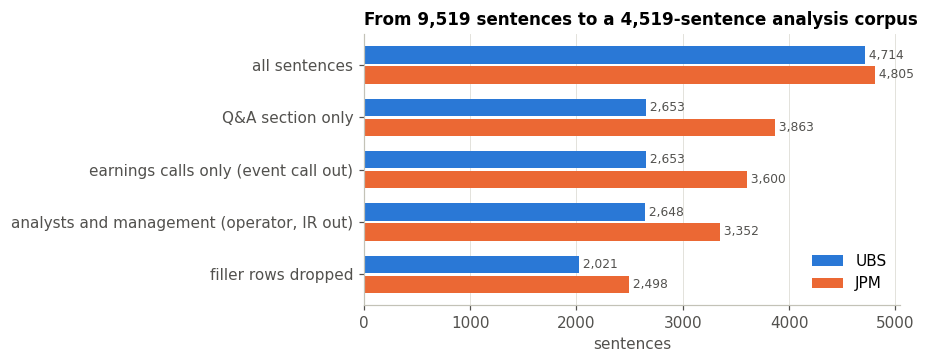

sentences  filler  filler_%
bank speaker_role                             
JPM  analyst            1125     448      39.8
     management         2227     406      18.2
UBS  analyst            1152     452      39.2
     management         1496     175      11.7

In [21]:
# 2.2 filter funnel with reasons, and the filler share by bank and role (N13)
fig, ax = plt.subplots(figsize=(8.5, 3.4))
y, h = np.arange(len(funnel)), 0.38
for i, b in enumerate(BANKS):
    ys = y + (i - 0.5) * h
    ax.barh(ys, funnel[b], height=h - 0.05, color=BANK_COLOR[b], label=b)
    for yy, v in zip(ys, funnel[b]):
        ax.text(v, yy, f" {v:,}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, funnel.index)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("sentences")
ax.legend(loc="lower right")
ax.set_title(f"From {funnel['total'].iloc[0]:,} sentences to a "
             f"{funnel['total'].iloc[-1]:,}-sentence analysis corpus", loc="left")
plt.tight_layout()
plt.show()

filler_share = (pre.assign(filler_row=pre["filler"] != "")
                .groupby(["bank", "speaker_role"])["filler_row"].agg(sentences="size", filler="sum"))
filler_share["filler_%"] = (100 * filler_share["filler"] / filler_share["sentences"]).round(1)
display(filler_share)

> **Business view.** The funnel chart is ready for the team's data slide. The table under it shows that about 40% of analyst sentences at both banks are courtesy or very short lines, against 12% of UBS and 18% of JPMorgan management sentences. Analysts spend many words on greetings and framing, so without the filter their "topics" would be diluted by politeness, and raw sentence counts would overstate how much they actually ask.

c:\local_CAM\Emp_Proj\boe-financial-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utterances  median_chars  median_tokens  over_MiniLM_pct  \
bank speaker_role                                                             
JPM  analyst              287         225.0           51.0              0.7   
     management           335         437.0          104.0             24.5   
UBS  analyst              194         229.5           56.0              5.7   
     management           169        1007.0          228.0             38.5   

                   over_mpnet_pct  qa_sentences_per_utterance  
bank speaker_role                                              
JPM  analyst                  0.0                         3.9  
     management               9.0                         6.6  
UBS  analyst                  0.0                         5.9  
     management              18.3                         8.9

clean sentences longer than the MiniLM limit: 0 of 4,519 (longest 172 word-pieces)


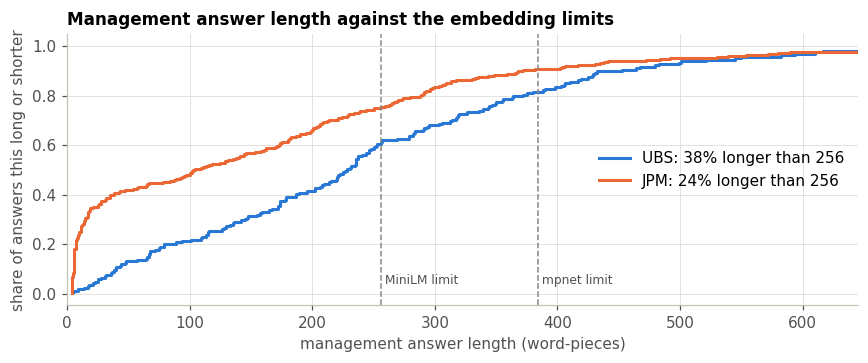

In [22]:
# 2.3 answer length in MiniLM word-pieces: how much of an answer an utterance-level embedding sees (N25)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
tok.model_max_length = 1_000_000          # counting only, so no truncation warning
LIMITS = {"MiniLM": 256, "mpnet": 384}    # max_seq_length of the two sentence-transformers

def n_tokens(texts):
    return np.array([len(ids) for ids in tok(list(texts))["input_ids"]])

answers = utt[(utt["section"] == "qa") & (utt["call_type"] == "earnings")
              & utt["speaker_role"].isin(ROLES)].copy()
answers["tokens"] = n_tokens(answers["text"])
qa["tokens"] = n_tokens(qa["text"])

length = answers.groupby(["bank", "speaker_role"]).agg(
    utterances=("tokens", "size"),
    median_chars=("text_length", "median"),
    median_tokens=("tokens", "median"),
    over_MiniLM_pct=("tokens", lambda t: 100 * (t > LIMITS["MiniLM"]).mean()),
    over_mpnet_pct=("tokens", lambda t: 100 * (t > LIMITS["mpnet"]).mean()))
length["qa_sentences_per_utterance"] = (pre.groupby(["bank", "speaker_role", "turn_id"]).size()
                                        .groupby(["bank", "speaker_role"]).mean())
display(length.round(1))
print(f"clean sentences longer than the MiniLM limit: {(qa['tokens'] > LIMITS['MiniLM']).sum()} "
      f"of {len(qa):,} (longest {qa['tokens'].max()} word-pieces)")

fig, ax = plt.subplots(figsize=(8, 3.4))
mgmt = answers[answers["speaker_role"] == "management"]
for b in BANKS:
    t = np.sort(mgmt.loc[mgmt["bank"] == b, "tokens"].to_numpy())
    ax.step(t, np.arange(1, len(t) + 1) / len(t), where="post", color=BANK_COLOR[b],
            label=f"{b}: {100 * (t > LIMITS['MiniLM']).mean():.0f}% longer than {LIMITS['MiniLM']}")
for name, lim in LIMITS.items():
    ax.axvline(lim, color="#898781", lw=1, ls="--")
    ax.text(lim, 0.04, f" {name} limit", fontsize=8, color="#52514e")
ax.set_xlim(0, mgmt["tokens"].quantile(0.98))
ax.set_xlabel("management answer length (word-pieces)")
ax.set_ylabel("share of answers this long or shorter")
ax.set_title("Management answer length against the embedding limits", loc="left")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

> **Business view.** Embedding models can only read a limited amount of text at once (256 word-pieces for MiniLM, 384 for mpnet) and silently ignore the rest. UBS executives give much longer answers than JPMorgan's (median 228 word-pieces against 104), and 38% of UBS management answers are longer than MiniLM's limit, against 24% at JPMorgan. Had we embedded whole answers, the model would have missed the end of more than a third of UBS answers, and UBS would look different from JPMorgan partly because of length rather than content. Working sentence by sentence removes the problem: the longest clean sentence is 172 word-pieces, inside both limits. This is the main technical reason for the sentence-level design.

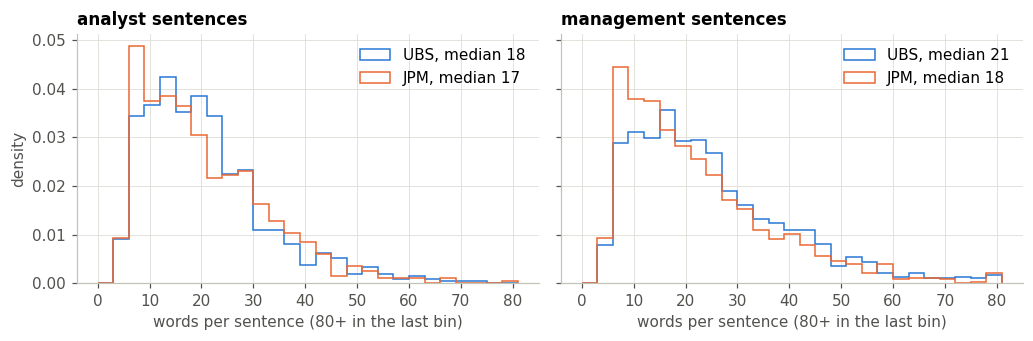

count  mean   std  min   50%   95%    max
bank speaker_role                                            
JPM  analyst        677.0  20.0  11.9  5.0  17.0  42.0   78.0
     management    1821.0  21.9  14.9  5.0  18.0  50.0  139.0
UBS  analyst        700.0  20.4  11.9  5.0  18.0  45.0   73.0
     management    1321.0  24.2  15.0  5.0  21.0  53.0  132.0

In [23]:
# 2.4 sentence length after cleaning, by bank and role
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
bins = np.arange(0, 82, 3)
for ax, role in zip(axes, ROLES):
    for b in BANKS:
        w = qa.loc[(qa["bank"] == b) & (qa["speaker_role"] == role), "n_words"]
        ax.hist(w.clip(upper=80), bins=bins, density=True, histtype="step", lw=2,
                color=BANK_COLOR[b], label=f"{b}, median {w.median():.0f}")
    ax.set_title(f"{role} sentences", loc="left")
    ax.set_xlabel("words per sentence (80+ in the last bin)")
    ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()
display(qa.groupby(["bank", "speaker_role"])["n_words"].describe(percentiles=[0.5, 0.95]).round(1))

> **Business view.** After cleaning, sentences from both banks have similar lengths (medians of 17 to 21 words, 95% under 55 words). Speaking style is comparable, so differences found later come from *what* is said, not from how long the sentences are. UBS management sentences are slightly longer (median 21 words against 18).

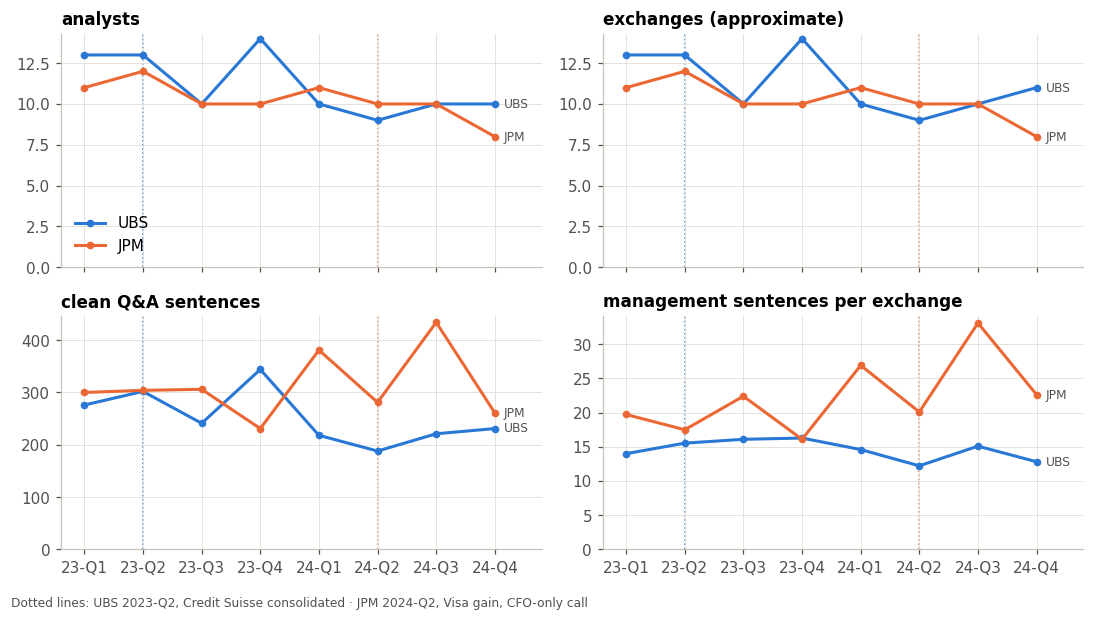

analysts     exchanges (approximate)       clean Q&A sentences       \
bank         JPM UBS                     JPM   UBS                 JPM  UBS   
quarter                                                                       
2023-Q1       11  13                    11.0  13.0                 300  276   
2023-Q2       12  13                    12.0  13.0                 304  302   
2023-Q3       10  10                    10.0  10.0                 306  241   
2023-Q4       10  14                    10.0  14.0                 231  344   
2024-Q1       11  10                    11.0  10.0                 381  218   
2024-Q2       10   9                    10.0   9.0                 281  188   
2024-Q3       10  10                    10.0  10.0                 434  221   
2024-Q4        8  10                     8.0  11.0                 261  231   

        management sentences      management sentences per exchange        
bank                     JPM  UBS                               JPM   UBS  
quarter                                                                    
2023-Q1                  217  182                              19.7  14.0  
2023-Q2                  210  202                              17.5  15.5  
2023-Q3                  224  161                              22.4  16.1  
2023-Q4                  161  228                              16.1  16.3  
2024-Q1                  296  146                              26.9  14.6  
2024-Q2                  201  110                              20.1  12.2  
2024-Q3                  331  151                              33.1  15.1  
2024-Q4                  181  141                              22.6  12.8

In [24]:
# 2.5 Q&A volume per earnings call: analysts, exchanges, and how much management says per exchange
turns = utt[(utt["section"] == "qa") & (utt["call_type"] == "earnings")]
by_call = ["bank", "quarter"]
volume = pd.DataFrame({
    "analysts": turns[turns["speaker_role"] == "analyst"].groupby(by_call)["speaker_name"].nunique(),
    "exchanges (approximate)": turns.groupby(by_call)["exchange"].max(),
    "clean Q&A sentences": qa.groupby(by_call).size(),
    "management sentences": qa[qa["speaker_role"] == "management"].groupby(by_call).size(),
})
volume["management sentences per exchange"] = (volume["management sentences"]
                                               / volume["exchanges (approximate)"])
panels = ["analysts", "exchanges (approximate)", "clean Q&A sentences", "management sentences per exchange"]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
for ax, col in zip(axes.flat, panels):
    bank_lines(ax, volume[col], col)
    ax.set_ylim(bottom=0)
axes[0, 0].legend(loc="lower left")
fig.text(0.01, 0.005, BREAK_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()
display(volume.round(1).unstack("bank"))

> **Business view.** How much Q&A each call has. Both banks take questions from 8 to 14 analysts per call, roughly one exchange each. The difference is in the answers. JPMorgan management says 16 to 33 sentences per exchange, peaking in 2024-Q3, while UBS stays steady at 12 to 16. So JPMorgan answers at greater length, which is another reason the comparison works with per-sentence shares rather than totals.

In [25]:
# 2.6 who asks: analysts and houses per bank, and the houses on both banks' calls
an = utt[utt["speaker_role"] == "analyst"]
houses = an.groupby(["speaker_institution", "bank"])["speaker_name"].nunique().unstack(fill_value=0)
both = houses[(houses > 0).all(axis=1)]
people_both = set(an.loc[an["bank"] == "UBS", "speaker_name"]) & set(an.loc[an["bank"] == "JPM", "speaker_name"])
print(f"analysts: UBS {an.loc[an['bank'] == 'UBS', 'speaker_name'].nunique()}, "
      f"JPM {an.loc[an['bank'] == 'JPM', 'speaker_name'].nunique()}; "
      f"same person on both banks' calls: {sorted(people_both) or 'none'}")
print(f"houses on both banks' calls: {len(both)} of {len(houses)} (analysts per house)")
display(both)

analysts: UBS 18, JPM 16; same person on both banks' calls: none
houses on both banks' calls: 5 of 26 (analysts per house)


bank,JPM,UBS
speaker_institution,,
Autonomous Research,1,1
Bank of America,1,2
Deutsche Bank,1,1
Jefferies,1,1
Morgan Stanley,3,2


> **Business view.** Who asks the questions. UBS faces 18 analysts and JPMorgan 16, and no analyst appears on both banks' calls. Only 5 of 26 research houses (Autonomous, Bank of America, Deutsche Bank, Jefferies, Morgan Stanley) cover both. When the banks' Q&A differs, part of the reason may be that different people ask, not only that the banks differ. This is a caveat to state with every cross-bank finding.

In [26]:
# 2.7 merger talk by keyword: how often each deal is named, per bank and quarter (N20)
MERGER_KW = re.compile(r"(?i:credit suisse|first republic|\bintegrat\w*|\bacquisi\w*|\bmerger\w*)|\bCS\b|\bFRC\b")
qa["merger_keyword"] = qa["text"].str.contains(MERGER_KW)
kw = (qa.pivot_table(index="bank", columns="quarter", values="merger_keyword", aggfunc="sum")
        .reindex(columns=QUARTERS))
kw["total"] = kw.sum(axis=1)
kw["share_%"] = (100 * kw["total"] / qa.groupby("bank").size()).round(1)
display(kw)

quarter,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,total,share_%
bank,,,,,,,,,,
JPM,1,5,11,12,9,2,3,2,45,1.8
UBS,19,30,23,29,14,8,11,11,145,7.2


> **Business view.** A simple count of how often each deal is named ("Credit Suisse", "First Republic", "integration", "acquisition", "merger"): 145 UBS sentences (7.2% of its Q&A) against 45 at JPMorgan (1.8%). UBS talk of its deal peaks in 2023-Q2 (30 sentences) and stays high through 2023; JPMorgan's peaks later, in 2023-Q3 and Q4. It is a first read of how much each call is about its acquisition, before Phase 4 measures themes by meaning.

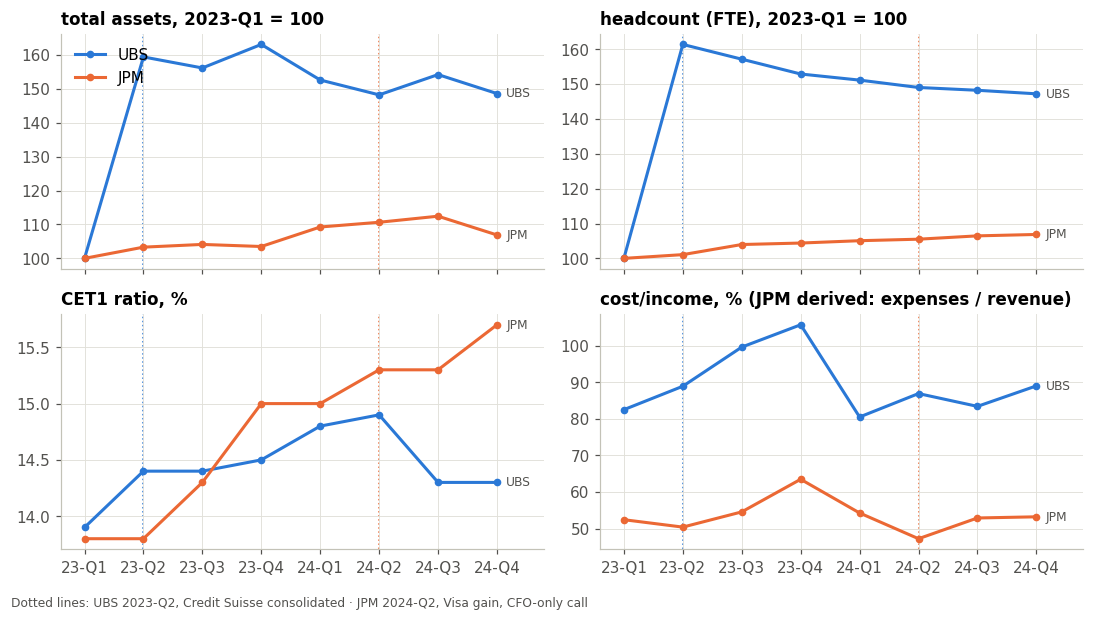

In [27]:
# 2.8 reported figures over time with breaks marked (JPM cost/income is derived, so labelled)
m = (metrics[metrics["basis"] == "reported"]
     .pivot_table(index=["bank", "quarter"], columns="metric_name", values="value"))
first = m.groupby(level="bank").transform("first")                     # 2023-Q1 values
series = {
    "total assets, 2023-Q1 = 100": 100 * m["total_assets"] / first["total_assets"],
    "headcount (FTE), 2023-Q1 = 100": 100 * m["personnel_fte"] / first["personnel_fte"],
    "CET1 ratio, %": m["cet1_ratio"],
    "cost/income, % (JPM derived: expenses / revenue)":
        m["cost_income_ratio"].fillna(100 * m["operating_expenses"] / m["total_revenues"]),
}
fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
for ax, (title, s) in zip(axes.flat, series.items()):
    bank_lines(ax, s, title)
axes[0, 0].legend(loc="upper left")
fig.text(0.01, 0.005, BREAK_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

> **Business view.** The reported numbers behind the talk. UBS total assets and headcount jump by about 60% in 2023-Q2, when Credit Suisse was consolidated, then fall slowly as the integration cuts costs and runs down assets. JPMorgan grows gently. UBS's cost/income ratio passes 100% in 2023-Q4 (costs above revenue during integration) before settling at 80 to 90%; JPMorgan stays near 50 to 60%. Both banks raise their CET1 capital ratio, with JPMorgan ahead from 2023-Q4. This is the context for Phase 4: if UBS executives talk more about costs and restructuring, the financials show why.

all 6,000 Q&A sentences, English stop words only: 15 of the top 20 are courtesy, filler or name words
filler rows dropped (4,519), English stop words only: 13 of the top 20 are courtesy, filler or name words
filler rows dropped (4,519), full stop list, the analysis view: 0 of the top 20 are courtesy, filler or name words


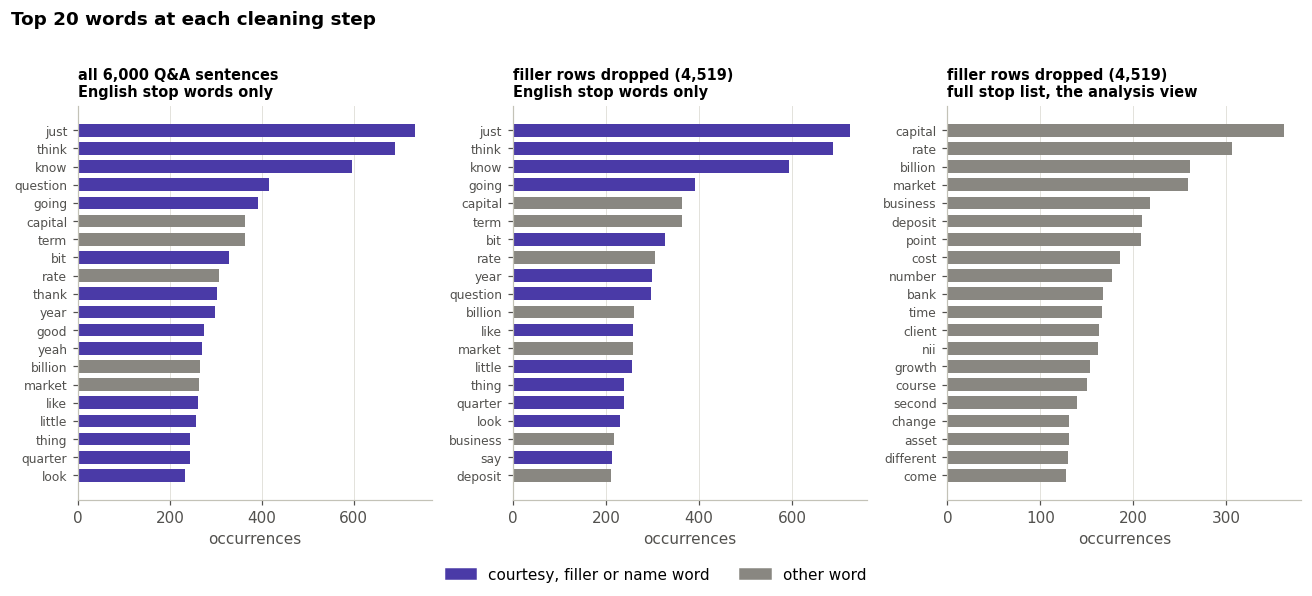

In [28]:
# 2.9 top 20 words before and after cleaning (R7): what a word count or word cloud shows at each step
views = {
    f"all {len(pre):,} Q&A sentences\nEnglish stop words only": pre["bow_en"],
    f"filler rows dropped ({len(qa):,})\nEnglish stop words only": qa["bow_en"],
    f"filler rows dropped ({len(qa):,})\nfull stop list, the analysis view": qa["bow"],
}
MARK, PLAIN = "#4a3aa7", "#898781"
fig, axes = plt.subplots(1, 3, figsize=(12, 5.4))
for ax, (title, col) in zip(axes, views.items()):
    top20 = pd.Series(Counter(t for toks in col for t in toks)).nlargest(20).iloc[::-1]
    noise = top20.index.isin(NOISE)
    ax.barh(top20.index, top20.to_numpy(), color=np.where(noise, MARK, PLAIN), height=0.7)
    ax.set_title(title, loc="left", fontsize=9.5)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("occurrences")
    print(f"{title.replace(chr(10), ', ')}: {int(noise.sum())} of the top 20 are courtesy, filler or name words")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=MARK, label="courtesy, filler or name word"), Patch(color=PLAIN, label="other word")],
           loc="lower center", ncol=2)
fig.suptitle("Top 20 words at each cleaning step", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

> **Business view.** What a word cloud would show at each cleaning step. On the raw Q&A, 15 of the 20 most frequent words are fillers or courtesies ("just", "think", "know", "going", "thank"); dropping filler sentences alone still leaves 13. Only with the full stop list do finance words take over: capital, rate, billion, market, deposit, cost, client, NII. This is the before-and-after for the cleaning slide (R7). It shows why the team drops filler rows and uses a stop list before any word-based analysis.

In [29]:
# 2.10 words each bank used unusually often at each deal stage (the word-cloud idea; the wordcloud package is
# not in requirements.txt). Lift = the word's share in the group over its share in the whole corpus; count in brackets.
MIN_COUNT = 8
overall = Counter(t for toks in qa["bow"] for t in toks)
total = sum(overall.values())
lifted = {}
for (b, g), d in qa.groupby(["bank", "stage_group"]):
    c = Counter(t for toks in d["bow"] for t in toks)
    n = sum(c.values())
    lift = pd.Series({w: (k / n) / (overall[w] / total) for w, k in c.items() if k >= MIN_COUNT})
    lifted[(b, g)] = pd.Series([f"{w} ({c[w]})" for w in lift.nlargest(10).index])
display(pd.DataFrame(lifted).reindex(columns=pd.MultiIndex.from_product([BANKS, STAGE_GROUPS])))

UBS                                                   JPM  \
             early             closing        integration          early   
0    guarantee (9)             at1 (8)       pre-tax (10)   exposure (8)   
1     clarity (11)       operation (8)    subsidiary (20)    longer (11)   
2    combined (11)          legacy (8)          apac (11)  recession (9)   
3       shift (11)  restructuring (12)        guided (17)      bank (40)   
4         mix (16)        combined (8)  transactional (8)       did (11)   
5  transaction (8)         natural (8)          tier (15)    economy (9)   
6       based (12)       non-core (13)      mid-teens (9)    higher (25)   
7       month (12)         quickly (9)   deleveraging (8)    driver (10)   
8  switzerland (8)            fair (9)         sweep (23)      money (8)   
9      client (35)             ncl (9)        parent (32)    credit (15)   

                                               
           closing                integration  
0       power (10)                   ipo (10)  
1  consequence (8)                obvious (9)  
2        beta (11)  non-interest-bearing (11)  
3     product (22)       interest-bearing (8)  
4     economy (13)              checking (13)  
5   follow-up (12)             numerator (11)  
6   liquidity (12)                   love (9)  
7       cycle (10)                    ccb (8)  
8      outcome (8)             syndicated (8)  
9     pricing (10)             deployment (9)

> **Business view.** Words each bank used unusually often at each deal stage, a table version of word clouds. They follow the story. UBS early on: guarantee, clarity, combined, clients, Switzerland; at closing: AT1 (the written-off Credit Suisse bonds), legacy, restructuring, non-core, NCL; during integration: parent, subsidiary, deleveraging, sweep. JPMorgan early on: exposure, recession, bank, economy, from the US regional bank failures; at closing: pricing, beta, liquidity, cycle; during integration: IPO, interest-bearing and checking deposits, deployment. It gives the Bank a quick, readable signal of what dominated each phase at each bank.

### Summary

All 17 calls match the README. The two banks run their calls differently: UBS opens with long prepared remarks, JPMorgan's calls are mostly Q&A, and JPMorgan management says more per exchange (16 to 33 sentences against 12 to 16). 38% of UBS management answers are too long for MiniLM against 24% at JPMorgan, which is why the analysis runs on sentences. No analyst covers both banks, and only 5 of 26 research houses do. Word counts show why cleaning matters: 15 of the 20 most frequent raw words are fillers, and none are after cleaning. The words each bank used most at each stage follow events: guarantee and clients at UBS early on, AT1 and legacy at closing, parent and subsidiary during integration; recession and bank exposure at JPMorgan in early 2023. The reported figures show the Credit Suisse step change in 2023-Q2 and UBS's cost/income above 100% in 2023-Q4.

**Business value.** This is the team's EDA in one place, with the caveats every comparison needs: compare shares rather than counts, mark the two break quarters, and remember that different analysts ask at each bank.

## Topic modelling on sentences

Owner in the team plan: Jack, building on John's first iteration. This section is a reference for that track, not a replacement for it.

**Fidelity note.** Beyond C3: BERTopic runs on sentences rather than whole answers (N25), with separate models for analysts and management, and the timeline uses `topics_over_time` per bank with the quarter as the timestamp.

In [30]:
# 3.1 sentence embeddings, computed once and cached next to the row keys they belong to (reused in Phase 4).
# The clean-corpus cache is shared with angelo.ipynb, so both notebooks use the same vectors.
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {"MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
          "mpnet": "sentence-transformers/all-mpnet-base-v2"}

def embed(tag, texts, keys, name="qa", folder=None, batch_size=64):
    folder = folder or SHARED
    path, key_path = folder / f"emb_{name}_{tag}.npy", folder / f"emb_{name}_{tag}_keys.csv"
    if path.exists() and key_path.exists() and pd.read_csv(key_path)["key"].tolist() == list(keys):
        print(f"{tag} ({name}): loaded from {path.name}")
        return np.load(path)
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    t0 = time.time()
    E = model.encode(list(texts), batch_size=batch_size, normalize_embeddings=True,
                     convert_to_numpy=True, show_progress_bar=True)
    print(f"{tag} ({name}): {E.shape[0]:,} x {E.shape[1]} in {time.time() - t0:.0f}s on {DEVICE}, "
          f"max_seq_length {model.max_seq_length}")
    np.save(path, E)
    pd.Series(list(keys), name="key").to_csv(key_path, index=False)
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return E

emb = {"MiniLM": embed("MiniLM", qa["text"], qa["key"])}
emb_pre = embed("MiniLM", pre["text"], pre["key"], name="pre", folder=OUT)   # the 6,000 before the filler filter, for 3.3

MiniLM (qa): loaded from emb_qa_MiniLM.npy
MiniLM (pre): loaded from emb_pre_MiniLM.npy


> **Business view.** Loads the sentence embeddings saved by `angelo.ipynb`, so both notebooks use exactly the same vectors, and embeds the 6,000 sentences from before the filler filter in 4 seconds on the GPU. Those extra vectors serve only the before-and-after test in 3.3.

In [31]:
# 3.2 BERTopic on the clean Q&A sentences of both banks: one topic space, so shares compare directly.
# fit_topics holds the settings, so the runs in 3.3 and the role models in 3.7 differ only where stated.
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

MIN_TOPIC = 15

def fit_topics(texts, E, stop_words, min_topic=MIN_TOPIC):
    model = BERTopic(
        embedding_model=MODELS["MiniLM"],
        umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=SEED),
        hdbscan_model=HDBSCAN(min_cluster_size=min_topic, min_samples=5, metric="euclidean",
                              cluster_selection_method="eom", prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=sorted(stop_words), ngram_range=(1, 2), min_df=3),
        top_n_words=10,
    )
    topics, _ = model.fit_transform(list(texts), embeddings=E)
    return model, np.asarray(topics)

t0 = time.time()
topic_model, topics = fit_topics(qa["text"], emb["MiniLM"], STOP_WORDS)
qa["topic"] = topics
print(f"fitted in {time.time() - t0:.0f}s")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6079.13it/s]


fitted in 22s


> **Business view.** Fits the main topic model. BERTopic groups the 4,519 clean sentences of both banks by meaning, in one shared topic space, so UBS and JPMorgan shares can be compared directly. The settings sit in one function, so every other run in this section changes one thing at a time. The result is identical to `angelo.ipynb`: 76 topics.

In [32]:
# 3.3 before-and-after runs for the fine-tuning slide (plan step 3.2): each change recorded with topic count,
# outlier share, diversity (share of distinct words among all top-10 words), and the name and courtesy words
# left in the labels. Runs B and C share the same clusters; only the stop list for the labels differs.
def bertopic_words(model, topic_arr):
    return {t: [w for w, _ in model.get_topic(t)][:10] for t in sorted(set(topic_arr)) if t >= 0}

def quality(words_by_topic):
    ws = list(words_by_topic.values())
    return {"topics": len(ws),
            "diversity": round(len({w for t in ws for w in t}) / max(1, sum(map(len, ws))), 2),
            "name words in top-10": sum(any(p in NAMES for p in w.split()) for t in ws for w in t),
            "courtesy or filler words in top-10": sum(any(p in COURTESY | filler_words for p in w.split())
                                                      for t in ws for w in t)}

RUN_COLS = ["unit", "documents", "topics", "outliers_%", "diversity",
            "name words in top-10", "courtesy or filler words in top-10"]

def run_row(name, n, topic_arr, words):
    return {"run": name, "unit": "sentence", "documents": f"{n:,}",
            "outliers_%": round(100 * float((topic_arr == -1).mean()), 1), **quality(words)}

def past_run(name, **given):
    return {"run": name, **{c: "not recorded" for c in RUN_COLS}, **given}

def show_runs(rows):
    return pd.DataFrame(rows).drop_duplicates("run", keep="last").set_index("run").reindex(columns=RUN_COLS)

top_words = bertopic_words(topic_model, topics)
found = list(top_words)
t0 = time.time()
model_a, topics_a = fit_topics(pre["text"], emb_pre, EN_STOP)
model_b, topics_b = fit_topics(qa["text"], emb["MiniLM"], EN_STOP)
print(f"two comparison fits in {time.time() - t0:.0f}s")
runs = [
    past_run("pilot, 20 Sep (R9)", unit="utterance", topics="67", **{"name words in top-10": "most topics"}),
    past_run("John, first iteration (R16)", unit="utterance", documents="852",
             topics="12 analyst, ~20 management", **{"outliers_%": "11 / 14"}),
    run_row("A: all Q&A sentences, English stop words", len(pre), topics_a, bertopic_words(model_a, topics_a)),
    run_row("B: filler rows dropped, English stop words", len(qa), topics_b, bertopic_words(model_b, topics_b)),
    run_row("C: filler rows dropped, full stop list (main model)", len(qa), topics, top_words),
]
del model_a, model_b
display(show_runs(runs))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9607.98it/s]


two comparison fits in 19s


,unit,documents,topics,outliers_%,diversity,name words in top-10,courtesy or filler words in top-10
run,,,,,,,
"pilot, 20 Sep (R9)",utterance,not recorded,67,not recorded,not recorded,most topics,not recorded
"John, first iteration (R16)",utterance,852,"12 analyst, ~20 management",11 / 14,not recorded,not recorded,not recorded
"A: all Q&A sentences, English stop words",sentence,"6,000",109,26.3,0.66,25,229
"B: filler rows dropped, English stop words",sentence,"4,519",76,34.8,0.81,4,100
"C: filler rows dropped, full stop list (main model)",sentence,"4,519",76,34.8,0.83,0,0


> **Business view.** The before-and-after table for the team's optimisation slide, one change at a time. On all 6,000 sentences with only common English stop words (run A), the model finds 109 topics, but their labels hold 25 names and 229 courtesy or filler words: many topics are politeness, not finance. Dropping filler sentences (B) gives 76 topics with 4 names and 100 filler words. Adding the full stop list (C) keeps the same 76 topics with no names and no filler words in the labels, and the highest diversity (0.83). The cost is a larger unassigned share (34.8% against 26.3%), because short content-free sentences no longer form topics of their own. B and C group the sentences identically: the stop list changes what the Bank reads, not how sentences are grouped.

In [33]:
# 3.4 topics: size, top words, and lean to one bank (share of each bank's sentences, 50 = even, 100 = UBS only)
counts = pd.crosstab(qa["topic"], qa["bank"])
rate = counts / counts.sum()
topic_table = pd.DataFrame({
    "sentences": counts.sum(axis=1),
    "UBS_lean": (100 * rate["UBS"] / rate.sum(axis=1)).round(0),
    "analyst_%": (100 * pd.crosstab(qa["topic"], qa["speaker_role"], normalize="index")["analyst"]).round(0),
    "top words": pd.Series({t: ", ".join(ws[:6]) for t, ws in top_words.items()}),
}).drop(index=-1, errors="ignore").sort_values("sentences", ascending=False)
pd.set_option("display.max_colwidth", 90)
display(topic_table.head(30))

,sentences,UBS_lean,analyst_%,top words
0,179,43.0,39.0,"capital, deploy, capital requirements, excess capital, excess, requirements"
1,123,36.0,48.0,"nii, ex, nii guidance, guidance, revenue, curve"
2,116,47.0,38.0,"deposit, deposits, sweep, deposit mix, betas, balances"
3,114,64.0,8.0,"plan, proposal, need, focused, takes, clarity"
4,93,54.0,47.0,"billion, exit, billion billion, 10 billion, million, exit rate"
5,93,23.0,33.0,"banks, banking, bank, investment, investment banking, commercial"
6,87,76.0,34.0,"2025, 2024, teens, mid, 2026, 2027"
7,80,32.0,15.0,"outcome, happen, speculate, difficult, model, happens"
8,75,72.0,20.0,"clients, client, segments, client segments, services, segment"
9,75,28.0,32.0,"rates, rate, recession, higher, fed, cuts"


> **Business view.** The 30 largest topics, with a lean score (50 = both banks equally, 100 = UBS only, 0 = JPMorgan only) and the share asked by analysts. Some topics belong to one bank: Credit Suisse (97), Switzerland and market share (100) and non-core legacy wind-down (100) are UBS; loans and mortgages (18) and headwinds and pressure (17) lean to JPMorgan. Capital, NII guidance and deposits are shared. Topic 7 (32, 85% management) is mostly JPMorgan executives declining to forecast. Topics 3 ("plan, proposal"), 12 ("let, second, answer"), 18 and 25 are procedural language rather than business themes, and are the first candidates to remove when the model is tuned.

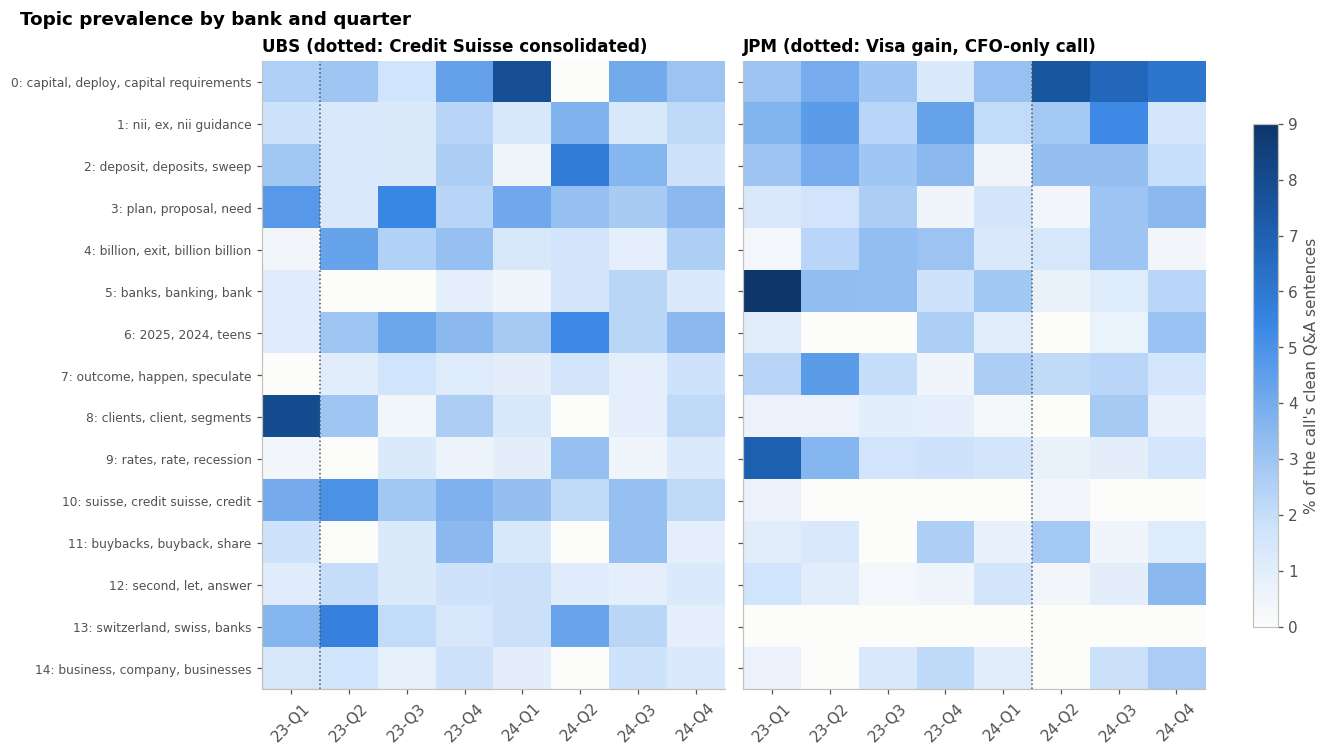

In [34]:
# 3.5 topic prevalence per bank and quarter: share of each call's clean Q&A sentences (outliers in the base)
TOP_K = 15
top = topic_table.index[:TOP_K].tolist()
share = pd.crosstab(qa["topic"], [qa["bank"], qa["quarter"]], normalize="columns")
vmax = 100 * share.loc[top].to_numpy().max()
fig, axes = plt.subplots(1, 2, figsize=(12, 0.33 * TOP_K + 1.8), sharey=True, layout="constrained")
for ax, b in zip(axes, BANKS):
    mat = 100 * share.loc[top, b].reindex(columns=QUARTERS)
    im = ax.imshow(mat.to_numpy(), aspect="auto", cmap=BLUES, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(QUARTERS)), QLABELS, rotation=45)
    ax.grid(False)
    ax.axvline(QUARTERS.index(BREAKS[b][0]) - 0.5, color="#52514e", lw=1, ls=":")
    ax.set_title(f"{b} (dotted: {BREAKS[b][1]})", loc="left")
axes[0].set_yticks(range(len(top)), [f"{t}: {', '.join(top_words[t][:3])}" for t in top], fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8, label="% of the call's clean Q&A sentences")
fig.suptitle("Topic prevalence by bank and quarter", x=0.01, ha="left", fontweight="bold")
plt.show()

> **Business view.** How much of each call is spent on each topic (darker = more). The pattern follows real events. UBS 2023-Q1, days after the rescue, is dominated by clients (topic 8: keeping and winning back Credit Suisse clients), and Credit Suisse and the Swiss market (10, 13) stay visible into 2024. JPMorgan 2023-Q1, during the US regional bank failures, is dominated by the banking sector and rates (5, 9). From 2024-Q2 JPMorgan's Q&A shifts to capital (topic 0: excess capital, deployment). That the topics move with the news is evidence the method picks up real information, which is the Bank's first business question.

In [35]:
# 3.6 five sentences nearest each topic's centre, for naming by a finance reader (Step 3.5).
# Prints transcript text: clear outputs before committing.
E = emb["MiniLM"]
topic_arr = qa["topic"].to_numpy()
for t in top:
    idx = np.flatnonzero(topic_arr == t)
    nearest = idx[np.argsort(-(E[idx] @ E[idx].mean(axis=0)))[:5]]
    print(f"\ntopic {t} · {len(idx)} sentences · {', '.join(top_words[t][:6])}")
    for i in nearest:
        print(f"   {qa.at[i, 'bank']} {qa.at[i, 'quarter']} {qa.at[i, 'speaker_role'][:4]}  {qa.at[i, 'text'][:170]}")

qa[["key", "sentence_id", "topic"]].to_csv(OUT / "topics_sentence_MiniLM.csv", index=False)


topic 0 · 179 sentences · capital, deploy, capital requirements, excess capital, excess, requirements
   JPM 2024-Q2 mana  So, given all that, putting it all together, and sorry for the long answer, we remain comfortable with the current amount of excess capital.
   JPM 2024-Q3 mana  We're can always deploy more capital if we want.
   JPM 2024-Q1 mana  And as Jamie says, the capital is earnings in store, and right now we don't see a lot of really compelling opportunities to deploy the capital.
   JPM 2024-Q1 mana  I urge all the analysts to keep in mind, excess capital is not wasted capital, it's earnings in store.
   UBS 2023-Q3 mana  And this will be in conflict with capital accretion and the ability for us to return capital to shareholders.

topic 1 · 123 sentences · nii, ex, nii guidance, guidance, revenue, curve
   JPM 2023-Q2 anal  And then secondly, and probably more importantly, can you help us think about the implications of higher-for-longer rates on the outlook for NII next

> **Business view.** For each of the 15 largest topics, the five sentences closest to the topic's centre. Word lists can mislead; real sentences show what a topic is about, and they are the input for naming the topics with a finance reader. Topic 7, for example, turns out to be JPMorgan management declining to forecast ("we are not predicting when", "we don't really know what's going to happen"), which its word list ("outcome, happen, speculate") only hints at. The topic of every sentence is saved for joining with Jack's track later (step 4.9).

In [36]:
# 3.7 one model for analysts and one for management (plan step 3.1). The Bank's first question is about the
# topics analysts raise. Analysts have fewer sentences, so their minimum topic size is 10 instead of 15.
def lean_table(frame, topic_arr, words):
    counts = pd.crosstab(topic_arr, frame["bank"].to_numpy())
    rate = counts / counts.sum()
    return pd.DataFrame({
        "sentences": counts.sum(axis=1),
        "UBS_lean": (100 * rate["UBS"] / rate.sum(axis=1)).round(0),
        "top words": pd.Series({t: ", ".join(ws[:6]) for t, ws in words.items()}),
    }).drop(index=-1, errors="ignore").sort_values("sentences", ascending=False)

role_topics, role_tables = {}, {}
t0 = time.time()
for role, min_topic in (("analyst", 10), ("management", MIN_TOPIC)):
    mask = qa["speaker_role"].eq(role).to_numpy()
    model, arr = fit_topics(qa.loc[mask, "text"], emb["MiniLM"][mask], STOP_WORDS, min_topic)
    words = bertopic_words(model, arr)
    qa.loc[mask, "topic_role"] = [f"{role[0].upper()}{t}" for t in arr]
    role_topics[role], role_tables[role] = arr, lean_table(qa[mask], arr, words)
    runs.append(run_row(f"{role} sentences only (min size {min_topic})", len(arr), arr, words))
    del model
print(f"two role models in {time.time() - t0:.0f}s")
display(show_runs(runs).tail(2))
print("topics raised by analysts (lean: 50 = even, 100 = UBS only, 0 = JPM only)")
display(role_tables["analyst"])
print("management topics, 20 largest")
display(role_tables["management"].head(20))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10380.94it/s]


two role models in 22s


,unit,documents,topics,outliers_%,diversity,name words in top-10,courtesy or filler words in top-10
run,,,,,,,
analyst sentences only (min size 10),sentence,"1,377",43,29.8,0.79,0,1
management sentences only (min size 15),sentence,"3,142",45,37.6,0.84,0,0


topics raised by analysts (lean: 50 = even, 100 = UBS only, 0 = JPM only)


,sentences,UBS_lean,top words
0,80,50.0,"capital, capital requirements, requirements, excess capital, second capital, earnings"
1,48,28.0,"deposit, deposits, mix, consumer, seeing, deposit growth"
2,44,47.0,"trying, appreciate, fair, understand, thoughts, thinking"
3,39,20.0,"nii, deposit, forecast, billion, 18, outlook"
4,37,45.0,"buybacks, buyback, 2025, position, saying, especially"
5,32,74.0,"runoff, natural, number, 12, trying, consensus"
6,30,53.0,"credit, private, fully, bank, investment bank, group"
7,29,72.0,"cet1, ratio, 15, chf, 14, buyback"
8,29,34.0,"nii, ex, forward, guidance, curve, forward curve"
9,27,40.0,"basel, basel iii, iii, endgame, iii endgame, basis points"


management topics, 20 largest


,sentences,UBS_lean,top words
0,124,17.0,"lending, loan, credit, loans, loan growth, private"
1,115,59.0,"plan, need, doing, time, focused, gap"
2,96,56.0,"business, efficiency, competition, team, wealth, company"
3,94,42.0,"banking, banks, bank, dcm, investment, investment banking"
4,86,35.0,"nii, duration, ex, extending, rate, rates"
5,86,37.0,"outcome, changed, difficult, predict, happen, model"
6,72,50.0,"deposit, deposits, balances, deposit balances, rate, margin"
7,66,98.0,"credit suisse, suisse, credit, ubs, ag, franchise"
8,57,76.0,"2025, 2024, 2026, february, early, update"
9,54,41.0,"let, answer, second, add, asking, couple"


> **Business view.** Separate models for analysts and management, because the Bank's first question is about what analysts raise. Analysts' 1,377 sentences form 43 topics, and many clearly belong to one bank (100 = UBS only, 0 = JPMorgan only). UBS analysts ask about Switzerland and the capital ordinance (100), non-core and the path to core returns (100), integration exits (91), cost saves (90), wealth management (89), mid-teens targets for 2026 (89), NCL guidance (87) and RWA (82). JPMorgan analysts ask about loans (7), card reserves (9), the banking industry (12), rates and the economy (13), NII forecasts (20) and deposits (28). Capital requirements, buybacks and Basel III endgame come up at both. Management's 3,142 sentences form 45 topics, led by lending (mostly JPMorgan) and the plan (mostly UBS). A few topics are procedural ("ask, answer", "follow-ups"); the finance reader will flag them.

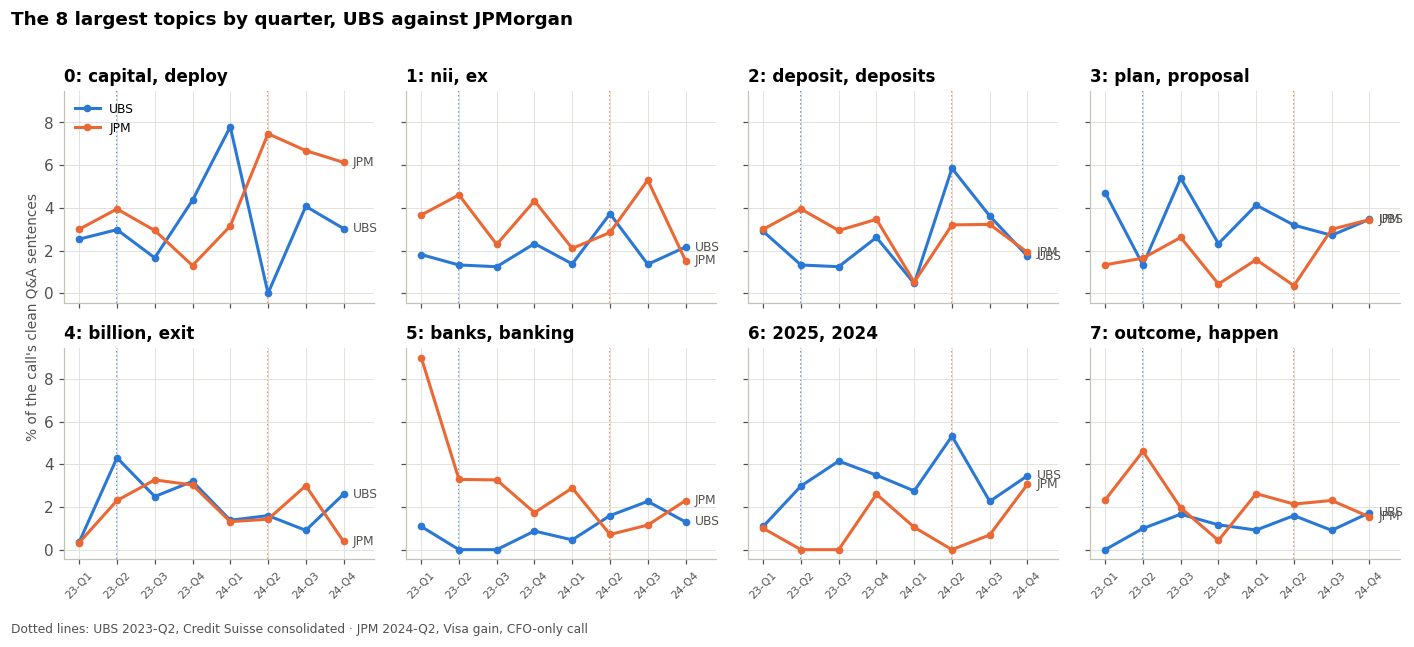


UBS, topic 13 (switzerland, swiss, banks): sentences and top words by quarter
         Frequency                                                         Words
quarter                                                                         
2023-Q1         10               switzerland, plenty, swiss, banks, market share
2023-Q2         17  switzerland, swiss, combined, market share, banking business
2023-Q3          5              switzerland, regional, combined, swiss, balanced
2023-Q4          5                swiss, 2024, integration, latest, structurally
2024-Q1          4                  switzerland, leading, serve, confused, facts
2024-Q2          8                  swiss, frtb, switzerland, nii guidance, work
2024-Q3          5                 100, swiss, impact, requirements, switzerland
2024-Q4          2            sensitivity, structure, remind, swiss, switzerland

JPM, topic 5 (banks, banking, bank): sentences and top words by quarter
         Frequency                    

In [37]:
# 3.8 topic timeline per bank, one point per quarter (plan step 3.3, N25): topics_over_time on each bank separately
# with the quarter as the timestamp, not 8 date bins that mix the two banks. global_tuning is off because this
# BERTopic version maps the global topic weights by position, which is wrong when a bank lacks a topic.
QIDX = {q: i for i, q in enumerate(QUARTERS)}
frames = []
for b in BANKS:
    d = qa[qa["bank"] == b]
    t = topic_model.topics_over_time(d["text"].tolist(), d["quarter"].map(QIDX).tolist(),
                                     topics=d["topic"].tolist(), global_tuning=False, evolution_tuning=False)
    t["bank"] = b
    t["quarter"] = [QUARTERS[int(i)] for i in t["Timestamp"]]
    t["share_%"] = 100 * t["Frequency"] / t["quarter"].map(d.groupby("quarter").size())
    frames.append(t)
over_time = pd.concat(frames, ignore_index=True)
over_time.to_csv(OUT / "topics_over_time.csv", index=False)

TIMELINE = top[:8]                                    # the 8 largest topics (3.5)
grid = pd.MultiIndex.from_product([BANKS, QUARTERS], names=["bank", "quarter"])
fig, axes = plt.subplots(2, 4, figsize=(13, 5.8), sharex=True, sharey=True)
for ax, t in zip(axes.flat, TIMELINE):
    s = (over_time[over_time["Topic"] == t].set_index(["bank", "quarter"])["share_%"]
         .reindex(grid, fill_value=0))
    bank_lines(ax, s, f"{t}: {', '.join(top_words[t][:2])}")
    ax.title.set_fontsize(9)
    ax.tick_params(axis="x", labelsize=7, rotation=45)
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.supylabel("% of the call's clean Q&A sentences", fontsize=9, color="#52514e")
fig.suptitle("The 8 largest topics by quarter, UBS against JPMorgan", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE, fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()

# how the words of each bank's most bank-specific large topic change from quarter to quarter
big = topic_table[topic_table["sentences"] >= 50]
for b, t in (("UBS", big["UBS_lean"].idxmax()), ("JPM", big["UBS_lean"].idxmin())):
    rows = over_time[(over_time["bank"] == b) & (over_time["Topic"] == t)].set_index("quarter")
    print(f"\n{b}, topic {t} ({', '.join(top_words[t][:3])}): sentences and top words by quarter")
    print(rows.reindex(QUARTERS)[["Frequency", "Words"]].fillna("").to_string())

> **Business view.** The eight largest topics over time, one line per bank and one point per quarter, showing when each subject mattered. JPMorgan's talk about the banking sector peaks in 2023-Q1 (9% of the call), during the US regional bank failures. Capital (topic 0) peaks at UBS in 2024-Q1 (7.8%) and at JPMorgan from 2024-Q2 (7.5%, staying above 6%). The words inside a topic also move: UBS's Swiss-market topic goes from market share and the combined bank in 2023 to requirements and sensitivity in 2024, and JPMorgan's banking-sector topic goes from regional banks to bank failures and the FDIC in 2024-Q1. For a supervisor this is the "what changed, and when" view per bank.

In [38]:
# 3.9 topic naming sheets for the finance reader (plan step 3.5), each sentence's topics for Phase 4 (plan step 3.6),
# and the run log. The sheets are written once and never overwritten, so names already entered are kept.
# The sheets hold transcript text; they stay under data/, which git ignores.
def naming_sheet(frame, E, topic_arr, table, n_topics):
    rows = []
    for t in table.index[:n_topics]:
        idx = np.flatnonzero(topic_arr == t)
        near = idx[np.argsort(-(E[idx] @ E[idx].mean(axis=0)))[:5]]
        examples = {f"example_{i + 1}": f"{frame['bank'].iat[j]} {frame['quarter'].iat[j]} "
                                        f"{frame['speaker_role'].iat[j][:4]}: {frame['text'].iat[j]}"
                    for i, j in enumerate(near)}
        rows.append({"topic": t, "sentences": len(idx), "UBS_lean": table.at[t, "UBS_lean"],
                     "top words": table.at[t, "top words"], **examples,
                     "name": "", "procedural (yes/no)": "", "agreed_by": ""})
    return pd.DataFrame(rows)

an_mask = qa["speaker_role"].eq("analyst").to_numpy()
sheets = {
    "topic_naming_joint.csv": naming_sheet(qa, emb["MiniLM"], qa["topic"].to_numpy(), topic_table, 30),
    "topic_naming_analyst.csv": naming_sheet(qa[an_mask].reset_index(drop=True), emb["MiniLM"][an_mask],
                                             role_topics["analyst"], role_tables["analyst"],
                                             len(role_tables["analyst"])),
}
for name, sheet in sheets.items():
    path = OUT / name
    if path.exists():
        print(f"kept {name} (never overwritten)")
    else:
        sheet.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"wrote {name}: {len(sheet)} topics to name")

qa[["key", "sentence_id", "topic", "topic_role"]].to_csv(OUT / "topics_by_sentence.csv", index=False)
run_log = show_runs(runs)
run_log.to_csv(OUT / "topic_runs.csv")
display(run_log)

kept topic_naming_joint.csv (never overwritten)
kept topic_naming_analyst.csv (never overwritten)


,unit,documents,topics,outliers_%,diversity,name words in top-10,courtesy or filler words in top-10
run,,,,,,,
"pilot, 20 Sep (R9)",utterance,not recorded,67,not recorded,not recorded,most topics,not recorded
"John, first iteration (R16)",utterance,852,"12 analyst, ~20 management",11 / 14,not recorded,not recorded,not recorded
"A: all Q&A sentences, English stop words",sentence,"6,000",109,26.3,0.66,25,229
"B: filler rows dropped, English stop words",sentence,"4,519",76,34.8,0.81,4,100
"C: filler rows dropped, full stop list (main model)",sentence,"4,519",76,34.8,0.83,0,0
analyst sentences only (min size 10),sentence,"1,377",43,29.8,0.79,0,1
management sentences only (min size 15),sentence,"3,142",45,37.6,0.84,0,0


> **Business view.** Writes two naming sheets for the finance reader: the 30 largest joint topics and all 43 analyst topics, each with its five most typical sentences and blank columns for a name, a procedural flag and who agreed it. Topics only mean something to the Bank once a finance reader has named them (plan step 3.5), and the procedural flag says which topics to drop when the model is tuned. The sheets are never overwritten, so names already entered are safe. The cell also saves each sentence's topics for Phase 4 and the run log from 3.3 and 3.7.

### Summary

The main BERTopic model on the 4,519 clean sentences finds 76 topics, leaves 34.8% of sentences unassigned, has a diversity of 0.83 and no names or filler words in its labels, identical to `angelo.ipynb`. The before-and-after runs show where the gain comes from: without cleaning the model finds 109 topics whose labels hold 25 names and 229 filler words, and dropping filler rows plus the stop list removes both. Separate models find 43 analyst topics and 45 management topics. Many analyst topics belong to one bank: Switzerland, non-core, integration exits, wealth management and cost saves at UBS; loans, card reserves, rates and the economy at JPMorgan. Capital requirements, buybacks and Basel III endgame come up at both. The timeline shows JPMorgan's banking-sector talk peaking in 2023-Q1, and capital becoming a leading topic at UBS in 2024-Q1 and at JPMorgan from 2024-Q2. Topic names wait for the finance reader (two sheets in `notebooks/angelo/outputs/2026-09-23/full/`).

**Business value.** Topics found without any labels already separate the two banks' agendas and move with real events, which answers part of the Bank's first question: what analysts raise, and how it changes. Next: name the topics, flag the procedural ones, then tune.

## Cross-bank comparison

Owner in the team plan: Willian. Steps 4.1 to 4.4 as first written for `angelo.ipynb`; from here this notebook follows its own branch. It keeps its own copy of the gold key and its own label sheets in `full/`.

In [39]:
# 4.1 corpus for the comparison: clean Q&A sentences, both banks on the same per-sentence footing
display(qa.pivot_table(index=["bank", "speaker_role"], columns="stage_group", values="key",
                       aggfunc="count", margins=True).reindex(columns=STAGE_GROUPS + ["All"]))

stage_group        early  closing  integration   All
bank speaker_role                                   
JPM  analyst          83       94          500   677
     management      217      210         1394  1821
UBS  analyst          94      100          506   700
     management      182      202          937  1321
All                  576      606         3337  4519

> **Business view.** The comparison corpus by bank, role and deal stage. Most sentences (3,337 of 4,519) fall in the integration period, because six of the eight quarters come after the deals closed. The early and closing stages have about 80 to 100 analyst and 180 to 220 management sentences per bank: enough for shares, but with wider uncertainty. That is why the gold set below samples every group equally.

In [40]:
# 4.2 second embedding model for the comparison (MiniLM is cached from 3.1)
emb["mpnet"] = embed("mpnet", qa["text"], qa["key"], batch_size=32)
for tag, E in emb.items():
    norms = np.linalg.norm(E, axis=1)
    print(f"{tag:7s} {E.shape[0]:,} x {E.shape[1]}   norms {norms.min():.3f} to {norms.max():.3f}")

mpnet (qa): loaded from emb_qa_mpnet.npy
MiniLM  4,519 x 384   norms 1.000 to 1.000
mpnet   4,519 x 768   norms 1.000 to 1.000


> **Business view.** Embeds the same sentences with a second, larger model (mpnet, 768 numbers per sentence, 27 seconds on the GPU). With two models we can test whether a finding is real or a quirk of one model: when both agree, the finding is more trustworthy. The norms of 1.000 confirm both are normalised, so their similarity scores are on the same scale.

### Theme codebook (anchors and gold labels)

| Label | Theme | A sentence belongs here when it is mainly about |
|---|---|---|
| `integration` | Integration and M&A | the 2023 acquisition, integration progress and milestones, client or system migration, legal-entity mergers, deal accounting |
| `restructuring` | Restructuring | winding down legacy or non-core books, exiting businesses, reorganisation, restructuring charges |
| `capital` | Capital and liquidity | capital ratios and requirements, buybacks and dividends, RWA and leverage, liquidity, funding, deposit outflows |
| `risk` | Risk and credit quality | credit losses and reserves, loan quality, real-estate exposure, market and rate risk, litigation |
| `costs` | Costs and efficiency | expenses, cost savings, cost/income, headcount, investment spend |
| `revenue` | Revenue and outlook | net interest income and deposit pricing, fees, trading, wealth flows, guidance, client activity |
| `other` | Other | none of the above, or procedure |

One theme per sentence (the main one), judged from the sentence alone. `sentiment` is the speaker's tone about the bank's business: `positive`, `neutral` or `negative`. `merger_related` is `yes` when the sentence is about either bank's 2023 acquisition or its integration, otherwise `no`. Save the sheets as **CSV UTF-8**.

In [41]:
# 4.3 theme anchors v1: five bank-neutral descriptions per theme (N20: no bank names)
ANCHORS_V1 = {
    "integration": [
        "The integration of the acquired bank is progressing well and we remain on track with our milestones.",
        "We are migrating the acquired clients and accounts onto our own platforms and systems.",
        "The merger of the two legal entities was completed after the transaction closed.",
        "Purchase accounting, negative goodwill and other acquisition-related effects from the deal.",
        "How is the combination of the two businesses going, and what are the remaining integration risks?",
    ],
    "restructuring": [
        "We continue to wind down the legacy portfolio and exit businesses that do not fit our strategy.",
        "Running off non-core positions released risk-weighted assets and reduced the balance sheet.",
        "The reorganisation involves closing overlapping units and simplifying the group structure.",
        "Restructuring charges and exit costs were higher this quarter.",
        "How much longer will it take to wind down the remaining legacy book?",
    ],
    "capital": [
        "Our CET1 capital ratio remains well above the regulatory requirement.",
        "We intend to return excess capital to shareholders through share buybacks and dividends.",
        "The proposed capital rules and Basel III requirements would increase the capital we need to hold.",
        "Liquidity and funding remain strong, with a comfortable liquidity coverage ratio.",
        "Risk-weighted assets and the leverage ratio determine how much balance sheet we can deploy.",
    ],
    "risk": [
        "Credit quality remains solid, but we expect net charge-offs to normalise from low levels.",
        "We added to our loan loss reserves because the macroeconomic outlook weakened.",
        "Exposure to commercial real estate and office loans is an area we are watching closely.",
        "Litigation, legal provisions and regulatory investigations remain a risk to earnings.",
        "Market volatility and geopolitical uncertainty could affect the portfolio.",
    ],
    "costs": [
        "We are on track to deliver the planned gross cost savings.",
        "Expenses rose this quarter, driven by investment in technology and higher compensation.",
        "Our cost-to-income ratio should improve as the efficiency measures come through.",
        "We reduced headcount and contractor spend to bring the cost base down.",
        "What is your expense guidance for next year?",
    ],
    "revenue": [
        "Net interest income will come down as deposit costs rise and balances move to higher-yielding products.",
        "Investment banking fees and markets revenue were strong compared with last year.",
        "Wealth management attracted net new assets and fee income grew.",
        "Our outlook assumes modest loan growth and a few rate cuts next year.",
        "Client activity and consumer spending remain healthy.",
    ],
}
THEMES = list(ANCHORS_V1) + ["other"]
THRESH_V1 = 0.30          # provisional: below it a sentence is "other"; tuned on the gold set in 4.5
BANK_NAMES = re.compile(r"\b(?:ubs|jp ?morgan|chase|credit suisse|first republic|swiss|switzerland)\b", re.I)
assert not any(BANK_NAMES.search(a) for v in ANCHORS_V1.values() for a in v), "an anchor names a bank"

def theme_scores(tag, anchors):
    # cosine similarity of every sentence to each theme's anchor centroid
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    centroids = []
    for texts in anchors.values():
        c = model.encode(texts, normalize_embeddings=True, convert_to_numpy=True).mean(axis=0)
        centroids.append(c / np.linalg.norm(c))
    del model
    return pd.DataFrame(emb[tag] @ np.vstack(centroids).T, columns=list(anchors))

def assign(scores, threshold):
    return scores.idxmax(axis=1).where(scores.max(axis=1) >= threshold, "other")

scores_v1 = {tag: theme_scores(tag, ANCHORS_V1) for tag in emb}
for tag, S in scores_v1.items():
    qa[f"theme_v1_{tag}"] = assign(S, THRESH_V1).to_numpy()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7543.51it/s]


> **Business view.** This is how each sentence gets a business theme. For each of the six themes the Bank cares about (integration and M&A, restructuring, capital and liquidity, risk, costs, revenue), we wrote five short example sentences, the "anchors". A sentence takes the theme whose anchors it is most similar to, or "other" if no theme is close enough (similarity below 0.30). The anchors never name a bank, and an automatic check enforces this, so the same yardstick is applied to UBS and JPMorgan. Unlike the BERTopic topics, these themes are fixed in advance and match the Bank's own questions.

In [42]:
# 4.3 diagnostics: best-theme similarity, share left as "other" at several thresholds, v1 theme shares
from sklearn.metrics import cohen_kappa_score

rows = []
for tag, S in scores_v1.items():
    best = S.max(axis=1)
    rows.append({"model": tag,
                 **{f"p{int(100 * q)}": round(best.quantile(q), 3) for q in (0.05, 0.25, 0.5, 0.75, 0.95)},
                 **{f"other_% at {t:.2f}": round(100 * (best < t).mean(), 1) for t in (0.20, 0.25, 0.30, 0.35, 0.40)}})
display(pd.DataFrame(rows).set_index("model"))

shares = pd.concat({tag: pd.crosstab(qa[f"theme_v1_{tag}"], qa["bank"], normalize="columns").mul(100).round(1)
                    for tag in emb}, axis=1).reindex(THEMES)
display(shares)
print(f"MiniLM and mpnet give the same theme for "
      f"{100 * (qa['theme_v1_MiniLM'] == qa['theme_v1_mpnet']).mean():.0f}% of sentences "
      f"(kappa {cohen_kappa_score(qa['theme_v1_MiniLM'], qa['theme_v1_mpnet']):.2f})")

print("\nmerger keywords (2.7) against the v1 integration theme, MiniLM")
display(pd.crosstab([qa["bank"], qa["merger_keyword"]], qa["theme_v1_MiniLM"].eq("integration")
                    .rename("integration theme"), margins=True))

,p5,p25,p50,p75,p95,other_% at 0.20,other_% at 0.25,other_% at 0.30,other_% at 0.35,other_% at 0.40
model,,,,,,,,,,
MiniLM,0.111,0.246,0.372,0.471,0.566,17.7,25.4,35.1,44.9,56.8
mpnet,0.103,0.240,0.361,0.446,0.551,18.2,26.6,36.2,47.6,61.7


MiniLM       mpnet      
bank             JPM   UBS   JPM   UBS
integration      3.2   6.9   3.4   8.6
restructuring    4.2   9.2   1.8   6.4
capital         12.1  15.7  15.6  16.1
risk            15.9   8.7  18.5  11.8
costs            6.1  12.3   6.6  15.0
revenue         20.7  15.5  14.2  10.3
other           37.8  31.8  39.8  31.8

MiniLM and mpnet give the same theme for 64% of sentences (kappa 0.55)

merger keywords (2.7) against the v1 integration theme, MiniLM


integration theme    False  True   All
bank merger_keyword                   
JPM  False            2382    71  2453
     True               37     8    45
UBS  False            1779    97  1876
     True              102    43   145
All                   4300   219  4519

> **Business view.** First results, before any tuning. At the 0.30 cut-off about 35% of sentences are "other"; the first table shows how that share moves with the cut-off (18% at 0.20, 57% at 0.40), so the cut-off is the main setting to tune on the gold set. In the theme shares, UBS spends more of its Q&A on integration (6.9% against 3.2%), restructuring (9.2% against 4.2%) and costs (12.3% against 6.1%), while JPMorgan spends more on risk (15.9% against 8.7%) and revenue (20.7% against 15.5%). Both models point the same way for every theme, which fits a bank absorbing a failed rival against one running business as usual. But the two models give the same theme to only 64% of sentences (kappa 0.55, moderate), so the model choice has to be settled on the gold set. The last table shows that the keywords and the integration theme overlap only partly (43 of 145 UBS keyword sentences): each finds sentences the other misses, and only human labels can say which is right.

In [43]:
# 4.3 check by eye: strongest and borderline sentences per theme (MiniLM v1).
# Prints transcript text: clear outputs before committing.
S, labels = scores_v1["MiniLM"], qa["theme_v1_MiniLM"].to_numpy()
for theme in ANCHORS_V1:
    idx = np.flatnonzero(labels == theme)
    order = idx[np.argsort(-S[theme].to_numpy()[idx])]
    print(f"\n{theme}: {len(idx)} sentences")
    for kind, picks in (("top ", order[:3]), ("edge", order[-3:])):
        for i in picks:
            print(f"   {kind} {S.at[i, theme]:.2f} {qa.at[i, 'bank']}  {qa.at[i, 'text'][:150]}")


integration: 219 sentences
   top  0.66 UBS  So, well, first of all, on the integration, of course, you know, now that we go through, as I mentioned, it's very important to understand the sequenc
   top  0.65 UBS  In terms of the acquired – you were asking business exits and the revenue attached.
   top  0.62 UBS  I'm convinced that a lot of the clients will see the value added of the combined businesses and some of those flows will revert.
   edge 0.31 UBS  And probably what I can offer as a comment is that as time goes by we saw it already in the second quarter of the year after the announcement of the t
   edge 0.30 UBS  In terms of your second question on the national charter and the timing, look, we're working on moving forward with getting the application in.
   edge 0.30 UBS  So, two examples where, and for different reasons of what excites us in terms of the acquisition.

restructuring: 291 sentences
   top  0.61 UBS  In terms of the restructuring you asked about, we'll come b

> **Business view.** A human sanity check: the three strongest and three weakest sentences for each theme. The strongest ones fit well ("we remain comfortable with the current amount of excess capital" is capital). The weakest, just above 0.30, are often wrong: "If I'm here for several more years, and I may or may not be Chairman" is tagged capital, and "And so, we calculate as such" is tagged costs. So the 0.30 cut-off is too loose at the edges, and these examples are concrete targets for the second version of the anchors.

In [44]:
# 4.4 gold set: 10 sentences per bank x role x stage group (120), split 60% tune / 40% test.
# Once gold_key.csv exists it is loaded, never redrawn, so labels stay attached to their sentences.
# This notebook keeps its own key and label sheets in OUT (its own branch). The first run copies the key drawn
# for angelo.ipynb, so both notebooks hold the same 120 sentences.
import shutil
STRATA = ["bank", "speaker_role", "stage_group"]
key_path = OUT / "gold_key.csv"
if not key_path.exists() and (SHARED / "gold_key.csv").exists():
    shutil.copy2(SHARED / "gold_key.csv", key_path)
if key_path.exists():
    gold = pd.read_csv(key_path)
    print(f"gold set loaded from {key_path.name}")
else:
    gold = (qa.groupby(STRATA).sample(n=10, random_state=SEED)
              [["key", "sentence_id"] + STRATA + ["quarter", "text"]]
              .sample(frac=1, random_state=SEED).reset_index(drop=True))
    gold.insert(0, "gold_id", [f"G{i:03d}" for i in range(1, len(gold) + 1)])
    gold["split"] = "tune"
    rng = np.random.default_rng(SEED)
    for _, g in gold.groupby(STRATA):
        gold.loc[rng.choice(g.index, size=4, replace=False), "split"] = "test"
    gold.to_csv(key_path, index=False)
    print(f"wrote {key_path.name}")
missing = set(gold["key"]) - set(qa["key"])
assert not missing, f"{len(missing)} gold sentences are no longer in the corpus"
display(gold.pivot_table(index=["bank", "speaker_role"], columns=["stage_group", "split"],
                         values="gold_id", aggfunc="count"))

# one blank sheet per labeller: text only (no bank or role), same order for both
LABELS = ["theme", "sentiment", "merger_related"]
SHEETS = {who: OUT / f"gold_labels_{who}.csv" for who in ("A_willian", "B_partner")}
for who, path in SHEETS.items():
    if path.exists():
        print(f"kept {path.name} (never overwritten)")
    else:
        (gold[["gold_id", "text"]].assign(**{c: "" for c in LABELS + ["note"]})
         .to_csv(path, index=False, encoding="utf-8-sig"))
        print(f"wrote {path.name}")

gold set loaded from gold_key.csv


stage_group       closing      early      integration     
split                test tune  test tune        test tune
bank speaker_role                                         
JPM  analyst            4    6     4    6           4    6
     management         4    6     4    6           4    6
UBS  analyst            4    6     4    6           4    6
     management         4    6     4    6           4    6

wrote gold_labels_A_willian.csv
wrote gold_labels_B_partner.csv


> **Business view.** Draws the "gold set": 120 real sentences, 10 from each mix of bank (2) × speaker role (2) × deal stage (3). Two people label them by hand, and their labels become the answer key for grading the automatic theme tagger. 72 sentences are used to tune the method (cut-off, anchor wording, model) and 48 are held back for the final score, so the method is not graded on the sentences it was tuned on. The sheets show only the text, without bank or speaker, so labellers cannot be swayed by knowing who said it. The draw is saved once and never redrawn, so labels always stay attached to the same sentences. In this notebook the key and the sheets are kept in `full/`; the key is a copy of the one drawn for `angelo.ipynb`, so the 120 sentences are the same.

In [45]:
# 4.4 agreement between the two labellers (Cohen's kappa); waits until both sheets are complete
ALLOWED = {"theme": set(THEMES), "sentiment": {"positive", "neutral", "negative"},
           "merger_related": {"yes", "no"}}

def read_sheet(path):
    # Excel may save with ";" or in a Windows code page; accept both
    for enc in ("utf-8-sig", "cp1252"):
        try:
            d = pd.read_csv(path, sep=None, engine="python", dtype=str, encoding=enc)
            break
        except UnicodeDecodeError:
            continue
    d = d.fillna("").set_index("gold_id")
    for c in LABELS:
        d[c] = d[c].str.strip().str.lower()
    return d

sheets = {who: read_sheet(p) for who, p in SHEETS.items()}
complete = {who: 100 * (d[LABELS] != "").all(axis=1).mean() for who, d in sheets.items()}
invalid = {who: {c: sorted(set(d[c]) - ALLOWED[c] - {""}) for c in LABELS} for who, d in sheets.items()}
if any(v for inv in invalid.values() for v in inv.values()):
    print("values outside the codebook:", invalid)
elif min(complete.values()) < 100:
    print("waiting for labels:", {who: f"{p:.0f}% complete" for who, p in complete.items()})
else:
    a = sheets["A_willian"]
    b = sheets["B_partner"].reindex(a.index)
    display(pd.DataFrame({"kappa": {c: cohen_kappa_score(a[c], b[c]) for c in LABELS},
                          "raw agreement": {c: (a[c] == b[c]).mean() for c in LABELS}}).round(2))
    agreed = a[LABELS].where(a[LABELS] == b[LABELS], "")
    to_settle = (agreed == "").any(axis=1).sum()
    final_path = OUT / "gold_final.csv"
    if final_path.exists():
        print(f"{final_path.name} already exists (never overwritten)")
    else:
        gold.set_index("gold_id")[["text"]].join(agreed).to_csv(final_path, encoding="utf-8-sig")
        print(f"wrote {final_path.name}: {to_settle} rows have blanks where the labellers disagreed; "
              "settle them together")

waiting for labels: {'A_willian': '0% complete', 'B_partner': '0% complete'}


> **Business view.** Once both labellers finish, this cell measures how often they agree using Cohen's kappa (agreement corrected for luck; above 0.6 is usually read as substantial). If two people cannot agree on a sentence's theme, a model cannot be expected to either, so kappa sets the ceiling for what "good" means. Sentences where they disagree are left blank in `gold_final.csv`, to be settled together. Both sheets are 0% complete, so the notebook stops here for now. In this notebook the sheets are kept in `full/`. Human labels are optional in this branch: the side section below uses Laya as the reference.

## Side project: Laya labels the gold set

Personal parallel track (PX in the plan), outside the team's four model families. Laya (`convaiinnovations/laya`, open weights, Apache 2.0, runs locally) is a "System 1" decision model: it answers typed questions about a text with a probability for every option, and never generates text. Here it labels the 120 gold sentences with the three codebook questions (theme, sentiment, merger yes or no), from the sentence alone, as a human labeller would. Its labels become this branch's reference, and the other methods are compared with it. Every score below is **agreement with a Laya reference**, not accuracy checked by people.

Laya runs in its own environment, `laya.venv` next to the repo, because installing it in the team `.venv` would change pinned packages and fail `verify()` (R18). The notebook writes the sentences to a file, runs Laya there, and reads the answers back.

Known limits from the model card: the base checkpoint is weak zero-shot, and its probabilities are over-confident until a temperature is fitted (PX5). Yes or no is asked as a two-option choice, because the English checkpoint's yes/no type can stick to one answer. Two control questions repeat the theme with the options reversed and the merger question with the options swapped; if Laya's answer changes with the order, its labels are less trustworthy.

**Questions v2 (after the first run).** In v1 Laya put 53% of the sentences in "other" and called only 2 merger-related. v2 drops "other" from the theme options and uses a probability cut-off instead, and asks the merger question in a second pass whose text also states the two 2023 deals. The v1 answers are kept, so the before and after sit side by side.

In [46]:
# PX0 Laya environment: its own venv next to the repo, so the team .venv keeps its pinned packages (R18).
# Built on the first run only: Python 3.13, CUDA torch (pip reuses the wheel cached for the team venv), then laya.
LAYA_CUDA = True                                   # False installs the smaller CPU build; 120 sentences run fine on CPU too
LAYA_VENV = ROOT.parent / "laya.venv"
LAYA_PY = LAYA_VENV / "Scripts" / "python.exe"
LAYA_DIR = OUT / "laya"
LAYA_DIR.mkdir(exist_ok=True)

def run_cmd(args, check=True):
    r = subprocess.run([str(a) for a in args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    if check and r.returncode != 0:
        print(r.stdout[-2000:], r.stderr[-3000:], sep="\n")
        raise RuntimeError(f"command failed (exit {r.returncode}): {' '.join(map(str, args[:4]))} ...")
    return r.stdout

if not LAYA_PY.exists():
    print(f"building {LAYA_VENV} (a few minutes, once)")
    run_cmd(["py", "-3.13", "-m", "venv", LAYA_VENV])
    run_cmd([LAYA_PY, "-m", "pip", "install", "-q", "--upgrade", "pip"])
    if LAYA_CUDA:
        run_cmd([LAYA_PY, "-m", "pip", "install", "-q", "torch", "--index-url", "https://download.pytorch.org/whl/cu126"])
    run_cmd([LAYA_PY, "-m", "pip", "install", "-q", "laya"])
info = run_cmd([LAYA_PY, "-c", "import sys, torch, laya; print(sys.version.split()[0], torch.__version__, "
                "torch.cuda.is_available(), getattr(laya, '__version__', '?'))"]).strip().splitlines()[-1].split()
LAYA_DEVICE = "cuda" if info[2] == "True" else "cpu"
print(f"laya.venv: python {info[0]}, torch {info[1]}, laya {info[3]}, device {LAYA_DEVICE}")

laya.venv: python 3.13.15, torch 2.14.0+cu126, laya 0.3.20, device cuda


> **Business view.** Builds Laya's own environment the first time the notebook runs, next to the repo, so the team environment keeps its exact package versions and its check still passes. It reused the CUDA build of PyTorch already on the laptop, so Laya runs on the GPU (Python 3.13.15, torch 2.14 with CUDA, laya 0.3.20). Keeping it apart means the side project can never break the team's reproducible setup.

In [47]:
# PX3 Laya labels the 120 gold sentences, questions v2 (v1 is kept for the before-and-after):
# - theme: the six themes without an "other" option; a sentence is "other" when Laya's top theme has a probability
#   below LAYA_OTHER_BELOW (provisional, like the anchors' 0.30). In v1, "other" took 53% of the sentences.
# - merger yes or no: asked in a second pass whose text also states the two 2023 deals. Theme and sentiment still
#   see the sentence alone, so the effect of each change stays separate.
# Answers are cached per version: delete laya_gold_v2.jsonl to run again.
import json, os

CODEBOOK_LAYA = {
    "integration": "an acquisition of another bank, integration progress, client or system migration, legal-entity mergers, deal accounting",
    "restructuring": "winding down legacy or non-core books, exiting businesses, reorganisation, restructuring charges",
    "capital": "capital ratios and requirements, buybacks and dividends, RWA and leverage, liquidity, funding, deposit outflows",
    "risk": "credit losses and reserves, loan quality, real-estate exposure, market and rate risk, litigation",
    "costs": "expenses, cost savings, cost/income, headcount, investment spend",
    "revenue": "net interest income and deposit pricing, fees, trading, wealth flows, guidance, client activity",
}
assert list(CODEBOOK_LAYA) == [t for t in THEMES if t != "other"]
DEALS = "In 2023 UBS acquired Credit Suisse, and JPMorgan acquired First Republic."
THEME_Q = "What is this sentence from a bank's earnings call mainly about?"
MERGER_Q = "Is this sentence about either bank's 2023 acquisition of another bank, or its integration?"
YES, NO = "yes, about the acquisition or its integration", "no, about something else"
LAYA_PASSES = [
    {"name": "sentence only", "context": None, "questions": {
        "theme": {"type": "choice", "instructions": THEME_Q, "criteria": CODEBOOK_LAYA},
        "theme_reversed": {"type": "choice", "instructions": THEME_Q,
                           "criteria": dict(reversed(list(CODEBOOK_LAYA.items())))},
        "sentiment": {"type": "choice", "instructions": "What is the speaker's tone about the bank's business?",
                      "criteria": {"positive": "favourable, confident or improving",
                                   "neutral": "factual, balanced or no view",
                                   "negative": "unfavourable, worried or deteriorating"}}}},
    {"name": "with the deals", "context": DEALS, "questions": {
        "merger_related": {"type": "choice", "instructions": MERGER_Q, "criteria": {"A": YES, "B": NO}},
        "merger_swapped": {"type": "choice", "instructions": MERGER_Q, "criteria": {"A": NO, "B": YES}}}},
]
LAYA_OTHER_BELOW = 0.5
LAYA_VERSION = "v2"
LAYA_REPO = "convaiinnovations/laya"               # the English checkpoint

LAYA_RUNNER = """
import argparse, csv, json, os, time
os.environ.setdefault("USE_TF", "0")
import torch
import laya

p = argparse.ArgumentParser()
for name in ("--inp", "--out", "--passes", "--repo", "--device"):
    p.add_argument(name, required=True)
p.add_argument("--batch-size", type=int, default=16)
a = p.parse_args()
passes = json.load(open(a.passes, encoding="utf-8"))
with open(a.inp, encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))
t0 = time.time()
try:
    agent = laya.load(a.repo, device=a.device)
except TypeError:
    agent = laya.load(a.repo)
load_s = time.time() - t0

def ask(states, questions):
    if hasattr(agent, "predict_batch"):
        try:
            return list(agent.predict_batch(states, questions, batch_size=a.batch_size, sort_by_length=False))
        except TypeError:
            pass
    return [agent.predict(s, questions) for s in states]

answers = [dict() for _ in rows]
t0 = time.time()
for ps in passes:
    states = [{"context": ps["context"], "sentence": r["text"]} if ps["context"] else {"sentence": r["text"]}
              for r in rows]
    results = ask(states, ps["questions"])
    assert len(results) == len(rows)
    for got, res in zip(answers, results):
        got.update(res["answers"])
run_s = time.time() - t0
tmp = a.out + ".tmp"
with open(tmp, "w", encoding="utf-8") as f:
    for r, got in zip(rows, answers):
        f.write(json.dumps({"gold_id": r["gold_id"], "answers": got}) + "\\n")
os.replace(tmp, a.out)
print(json.dumps({"laya": getattr(laya, "__version__", "?"), "torch": torch.__version__, "device": a.device,
                  "sentences": len(rows), "passes": len(passes), "load_s": round(load_s, 1), "run_s": round(run_s, 1)}))
"""

old_v1, v1_path = LAYA_DIR / "laya_gold.jsonl", LAYA_DIR / "laya_gold_v1.jsonl"
if old_v1.exists() and not v1_path.exists():
    old_v1.rename(v1_path)                         # the first run's answers, kept as v1
raw_path = LAYA_DIR / f"laya_gold_{LAYA_VERSION}.jsonl"
if raw_path.exists():
    print(f"Laya answers loaded from {raw_path.name}")
else:
    gold[["gold_id", "text"]].to_csv(LAYA_DIR / "laya_in.csv", index=False)
    passes_path = LAYA_DIR / f"passes_{LAYA_VERSION}.json"
    passes_path.write_text(json.dumps(LAYA_PASSES, indent=1), encoding="utf-8")
    (LAYA_DIR / "laya_runner.py").write_text(LAYA_RUNNER, encoding="utf-8")
    if DEVICE == "cuda":
        torch.cuda.empty_cache()                   # leave the GPU to the Laya process
    t0 = time.time()
    r = subprocess.run([str(x) for x in (LAYA_PY, LAYA_DIR / "laya_runner.py", "--inp", LAYA_DIR / "laya_in.csv",
                                         "--out", raw_path, "--passes", passes_path,
                                         "--repo", LAYA_REPO, "--device", LAYA_DEVICE)],
                       capture_output=True, text=True, encoding="utf-8", errors="replace",
                       env={**os.environ, "USE_TF": "0", "PYTHONIOENCODING": "utf-8"})
    if r.returncode != 0:
        print(r.stderr[-4000:])
        raise RuntimeError("the Laya run failed; its error is above")
    print(f"Laya ran in {time.time() - t0:.0f}s: {r.stdout.strip().splitlines()[-1]}")

def read_answers(path):
    return {row["gold_id"]: row["answers"] for row in map(json.loads, path.read_text(encoding="utf-8").splitlines())}

def top(answer):
    probs = answer["probabilities"]
    best = max(probs, key=probs.get)
    return best, probs[best]

MERGER_A, MERGER_SWAP = {"A": "yes", "B": "no"}, {"A": "no", "B": "yes"}
rows = []
for gid, a in read_answers(raw_path).items():
    theme_top, theme_p = top(a["theme"])
    rows.append({
        "gold_id": gid,
        "theme_laya_top": theme_top,
        "theme_laya_p": theme_p,
        "theme_laya": theme_top if theme_p >= LAYA_OTHER_BELOW else "other",
        "theme_laya_reversed_top": top(a["theme_reversed"])[0],
        "sentiment_laya": top(a["sentiment"])[0],
        "sentiment_laya_p": top(a["sentiment"])[1],
        "merger_laya": MERGER_A[top(a["merger_related"])[0]],
        "merger_laya_p_yes": a["merger_related"]["probabilities"]["A"],
        "merger_laya_swapped": MERGER_SWAP[top(a["merger_swapped"])[0]],
    })
laya_df = pd.DataFrame(rows)
assert set(laya_df["gold_id"]) == set(gold["gold_id"]), "Laya answers do not match the gold set: delete the jsonl file"

print(f'share of sentences that become "other" at each cut-off on the top theme probability (provisional {LAYA_OTHER_BELOW})')
display(pd.Series({f"below {c:.1f}": round(100 * (laya_df["theme_laya_p"] < c).mean(), 1)
                   for c in (0.3, 0.4, 0.5, 0.6, 0.7)}, name="other_%").to_frame().T)

counts = {f"v2 ({LAYA_VERSION}: 6 themes, other below {LAYA_OTHER_BELOW})": laya_df["theme_laya"].value_counts(),
          "v2 top theme, no cut-off": laya_df["theme_laya_top"].value_counts()}
merger_yes = {"v2 (the deals stated)": int((laya_df["merger_laya"] == "yes").sum())}
if v1_path.exists():
    v1 = read_answers(v1_path)
    counts = {"v1 (7 options, sentence only)": pd.Series([top(a["theme"])[0] for a in v1.values()]).value_counts(), **counts}
    merger_yes = {"v1 (sentence only)": sum(MERGER_A[top(a["merger_related"])[0]] == "yes" for a in v1.values()), **merger_yes}
print("theme labels, before and after")
display(pd.DataFrame(counts).reindex(THEMES).fillna(0).astype(int))
print("merger-related sentences:", merger_yes, f"· mean P(yes) now {laya_df['merger_laya_p_yes'].mean():.2f}")
print("sentiment:", laya_df["sentiment_laya"].value_counts().to_dict())

Laya ran in 41s: {"laya": "0.3.20", "torch": "2.14.0+cu126", "device": "cuda", "sentences": 120, "passes": 2, "load_s": 7.1, "run_s": 31.5}
share of sentences that become "other" at each cut-off on the top theme probability (provisional 0.5)


,below 0.3,below 0.4,below 0.5,below 0.6,below 0.7
other_%,7.5,25.0,45.0,65.0,76.7


theme labels, before and after


,"v1 (7 options, sentence only)","v2 (v2: 6 themes, other below 0.5)","v2 top theme, no cut-off"
integration,3,3,4
restructuring,2,1,4
capital,12,11,15
risk,4,5,7
costs,3,3,4
revenue,32,43,86
other,64,54,0


merger-related sentences: {'v1 (sentence only)': 2, 'v2 (the deals stated)': 47} · mean P(yes) now 0.47
sentiment: {'neutral': 91, 'positive': 16, 'negative': 13}


In [48]:
# PX3 and PX4 how far to trust Laya (v2), and the other methods scored against it: the v1 anchors (MiniLM, mpnet)
# for the theme, the merger keywords and the anchors' integration theme for merger yes or no.
# Laya is the reference here, so every score is agreement with a Laya reference. The test rows use the 48
# held-back sentences only.
from sklearn.metrics import f1_score

pred = (gold[["gold_id", "key", "split", "bank", "speaker_role", "stage_group"]]
        .merge(qa[["key", "theme_v1_MiniLM", "theme_v1_mpnet", "merger_keyword"]], on="key", how="left")
        .merge(laya_df, on="gold_id", how="left")
        .rename(columns={"theme_v1_MiniLM": "theme_anchor_MiniLM", "theme_v1_mpnet": "theme_anchor_mpnet"}))
pred["merger_keyword"] = pred["merger_keyword"].map({True: "yes", False: "no"})
pred["merger_anchor"] = np.where(pred["theme_anchor_MiniLM"] == "integration", "yes", "no")
pred.drop(columns="key").to_csv(LAYA_DIR / f"gold_predictions_{LAYA_VERSION}.csv", index=False)

checks = {"theme top choice, options reversed": ("theme_laya_top", "theme_laya_reversed_top"),
          "merger, yes and no swapped": ("merger_laya", "merger_laya_swapped")}
print("order checks: does Laya give the same answer when the options are reordered?")
display(pd.DataFrame({"same answer_%": {k: 100 * (pred[a] == pred[b]).mean() for k, (a, b) in checks.items()},
                      "kappa": {k: cohen_kappa_score(pred[a], pred[b]) for k, (a, b) in checks.items()}}).round(2))

rows = []
for field, ref, methods in (("theme", "theme_laya", ["theme_anchor_MiniLM", "theme_anchor_mpnet"]),
                            ("merger_related", "merger_laya", ["merger_keyword", "merger_anchor"])):
    for m in methods:
        for part, d in (("all 120", pred), ("test 48", pred[pred["split"] == "test"])):
            rows.append({"field": field, "method": m, "sentences": part,
                         "agreement_%": round(100 * (d[m] == d[ref]).mean()),
                         "macro_F1": round(f1_score(d[ref], d[m], average="macro", zero_division=0), 2),
                         "kappa": round(cohen_kappa_score(d[ref], d[m]), 2)})
print("the other methods against the Laya reference")
display(pd.DataFrame(rows).set_index(["field", "method", "sentences"]))

print("theme, all 120: Laya (rows) against the MiniLM anchors (columns)")
display(pd.crosstab(pred["theme_laya"], pred["theme_anchor_MiniLM"], margins=True)
        .reindex(index=THEMES + ["All"], columns=THEMES + ["All"], fill_value=0))
print("merger yes or no: Laya against the keywords and the anchors")
display(pd.crosstab(pred["merger_laya"], [pred["merger_keyword"], pred["merger_anchor"]],
                    rownames=["Laya"], colnames=["keyword", "anchor"]))
print("sentiment by bank and role, Laya (share of each group's 30 sentences, %)")
display((100 * pd.crosstab([pred["bank"], pred["speaker_role"]], pred["sentiment_laya"], normalize="index"))
        .round(0).reindex(columns=["positive", "neutral", "negative"], fill_value=0))

order checks: does Laya give the same answer when the options are reordered?


,same answer_%,kappa
"theme top choice, options reversed",73.33,0.54
"merger, yes and no swapped",75.83,0.43


the other methods against the Laya reference


agreement_%  macro_F1  kappa
field          method              sentences                              
theme          theme_anchor_MiniLM all 120             38      0.27   0.18
                                   test 48             40      0.32   0.22
               theme_anchor_mpnet  all 120             40      0.38   0.21
                                   test 48             38      0.31   0.21
merger_related merger_keyword      all 120             63      0.44   0.08
                                   test 48             62      0.43   0.06
               merger_anchor       all 120             61      0.41   0.02
                                   test 48             60      0.42   0.02

theme, all 120: Laya (rows) against the MiniLM anchors (columns)


theme_anchor_MiniLM,integration,restructuring,capital,risk,costs,revenue,other,All
theme_laya,,,,,,,,
integration,0,0,0,1,0,0,2,3
restructuring,0,0,0,0,1,0,0,1
capital,0,1,5,1,3,0,1,11
risk,0,1,0,3,0,0,1,5
costs,0,0,0,0,3,0,0,3
revenue,1,4,4,2,2,11,19,43
other,3,3,6,9,4,5,24,54
All,4,9,15,16,13,16,47,120


merger yes or no: Laya against the keywords and the anchors


keyword  no     yes    
anchor   no yes  no yes
Laya                   
no       71   2   0   0
yes      44   0   1   2

sentiment by bank and role, Laya (share of each group's 30 sentences, %)


sentiment_laya     positive  neutral  negative
bank speaker_role                             
JPM  analyst            7.0     80.0      13.0
     management        13.0     63.0      23.0
UBS  analyst           10.0     83.0       7.0
     management        23.0     77.0       0.0

In [49]:
# PX3 the sentences to read by eye: where Laya and both anchors disagree on the theme, the sentences Laya now calls
# merger-related, and Laya's least sure theme answers. Prints transcript text: clear outputs before committing.
text_by_id = gold.set_index("gold_id")["text"]
split_votes = pred[(pred["theme_laya"] != pred["theme_anchor_MiniLM"]) & (pred["theme_laya"] != pred["theme_anchor_mpnet"])]
print(f"Laya disagrees with both anchors on {len(split_votes)} of 120 sentences; 8 of them:")
for _, r in split_votes.head(8).iterrows():
    print(f"   Laya {r['theme_laya']:13s} MiniLM {r['theme_anchor_MiniLM']:13s} mpnet {r['theme_anchor_mpnet']:13s}"
          f" {text_by_id[r['gold_id']][:110]}")
merger = pred[pred["merger_laya"] == "yes"].sort_values("merger_laya_p_yes", ascending=False)
print(f"\nsentences Laya calls merger-related ({len(merger)}), highest probability first:")
for _, r in merger.head(8).iterrows():
    print(f"   {r['merger_laya_p_yes']:.2f} keyword {r['merger_keyword']:3s} anchor {r['merger_anchor']:3s}"
          f" {text_by_id[r['gold_id']][:110]}")
print("\nLaya's 5 least sure theme answers (top probability)")
for _, r in pred.nsmallest(5, "theme_laya_p").iterrows():
    print(f"   {r['theme_laya_p']:.2f} {r['theme_laya_top']:13s} {text_by_id[r['gold_id']][:120]}")

Laya disagrees with both anchors on 65 of 120 sentences; 8 of them:
   Laya revenue       MiniLM restructuring mpnet other         That is not a particularly meaningful driver of the increase in NII guidance.
   Laya revenue       MiniLM risk          mpnet other         As I say, we always look quite closely inside the cohort, inside the income cohorts.
   Laya capital       MiniLM other         mpnet revenue       And maybe you can give some color on how your NII should pan out based on forward curves into 2024.
   Laya other         MiniLM risk          mpnet costs         Of course, we are – we will stay very focused on how we are present in that business.
   Laya other         MiniLM revenue       mpnet risk          And just as a follow up, I think the other risk from higher for longer rates, I think, is this – the ability o
   Laya other         MiniLM capital       mpnet risk          But now, if you look at our kind of end-of-period deposits this quarter and you project forwar

## Next

Stop here. Run everything, including the Laya section, and share the saved notebook. Then:

- read the v2 Laya results (PX3) and decide whether Laya is good enough to be this branch's reference before tuning the anchors against it
- the finance reader fills the two topic naming sheets in `notebooks/angelo/outputs/2026-09-23/full/`
- tuning is written from the outputs: Phase 3 (procedural topics, stop list, minimum topic size) and Phase 4 steps 4.5 to 4.10.